<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# extended-data-weekly-outputs-pca-week27

After the final milestone of the BBO capstone project is reached, this notebook reanalyses **weekly optimisation outputs across eight functions (F1–F8)** using clustering and dimensionality-reduction techniques.

### Overall Objective

Specifically, the notebook aims to answer two key questions:  
1. **Space Exploration**: Is the weekly optimisation algorithm exploring new/different regions of the input decision space over time?
2. **Performance Mapping**: Are the resulting clusters/regions in the input space associated with different levels of output performance?

### Visualisations
1. **Cluster Performance Analysis**: Evaluating whether high-performing optimisation solutions are concentrated within specific clusters.
2. **Temporal Tracking (Week 27 focus)**: Visualising how search trajectories evolve across weeks to check for convergence versus continued exploration.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

# Now import sklearn / KMeans
from sklearn.cluster import KMeans

import pandas as pd

In [2]:
file_path = "extended_data/CapstoneFunction_added_WeeklyOutput_final.xlsx"
if not os.path.exists(file_path):
    # Search for files in directory
    files = os.listdir('.')
    print("Files in current directory:", files)
else:
    xls = pd.ExcelFile(file_path)
    print("Sheet names:", xls.sheet_names)


Sheet names: ['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8']


## Compare initial (Given) and query (Weekly Update)

#### Plot 1: Output Value Distribution across 8 Functions (Given vs. Weekly Updates)

* **Variance & Range:** The baseline (`Given`) input sets span wide ranges across functions. Using a **SymLog scale**, functions like `F1`–`F4` show tightly clustered distributions around lower output baseline ranges, whereas functions like `F6`–`F8` exhibit much wider output variances.
* **Optimization Shift:** The weekly iterations (`Weekly Updates`) shift the distribution of output values significantly upward relative to the baseline `Given` points. This demonstrates that the optimization algorithm successfully identified input configurations that produce distinct (and typically higher/better) performance outputs compared to the random/initial design space.

#### Plot 2: Trajectory of Weekly Optimization Performance (Functions 1 to 8)

* **Convergence & Stability:** Across iterations (Weeks 2–13), the performance trajectories exhibit clear convergence behaviors:

  * **Low-Dimensional Functions (`F1`–`F4`):** Show rapid initial output gains in early weeks (Weeks 2–5) followed by asymptotic leveling, indicating early discovery of local/global optima.
  * **High-Dimensional Functions (`F7`, `F8`):** Display step-like or non-linear improvements, requiring more weekly iterations to break out of sub-optimal plateaus.
* **Optimizer Monotonicity:** Most functions exhibit progressive, near-monotonic improvements in output over time, confirming that the weekly black-box optimization routine effectively guides the search space toward higher-performing output regions.

#### Plot 3: PCA Projection of High-Dimensional Search Space (Function `F8`: 8D Input + 1D Output)

* **Dimensionality Reduction:** Function `F8` represents an 8-dimensional decision space collapsed via Principal Component Analysis (PCA) into a 2D joint coordinate space along **PC1** and **PC2**.
* **Separation of Search Regions:** Baseline (`Given`) points (blue) form a broad background cloud representing initial space exploration.
* **Trajectory Tracking:** Weekly optimization points (red stars annotated W2 to W13) branch away from the main cluster of `Given` points. This structural movement along the principal axes visually proves that the optimizer is **not merely resampling the initial domain**, but actively migrating toward a localized, high-performing region in the 8D input space.

#### Plot 4: Average Exploration Distance from `Given` Space

* **Distance Metric:** Measures the average Euclidean distance from each weekly optimization point to its nearest neighbor in the baseline `Given` input space.
* **Dimensional Dependency:**

  * **Lower-Dimensional Space (`F1` [2D], `F2` [3D]):** Exhibit smaller mean distances, as low-dimensional spaces are more densely sampled initially.
  * **Higher-Dimensional Space (`F7` [7D], `F8` [8D]):** Display significantly larger mean nearest-neighbor distances.
* **Conclusion on Exploration:** High-dimensional optimizers are forced to venture much farther from baseline design points to locate improved outputs, validating that the weekly search algorithm successfully escapes initial sampling regions to explore unmapped territory.


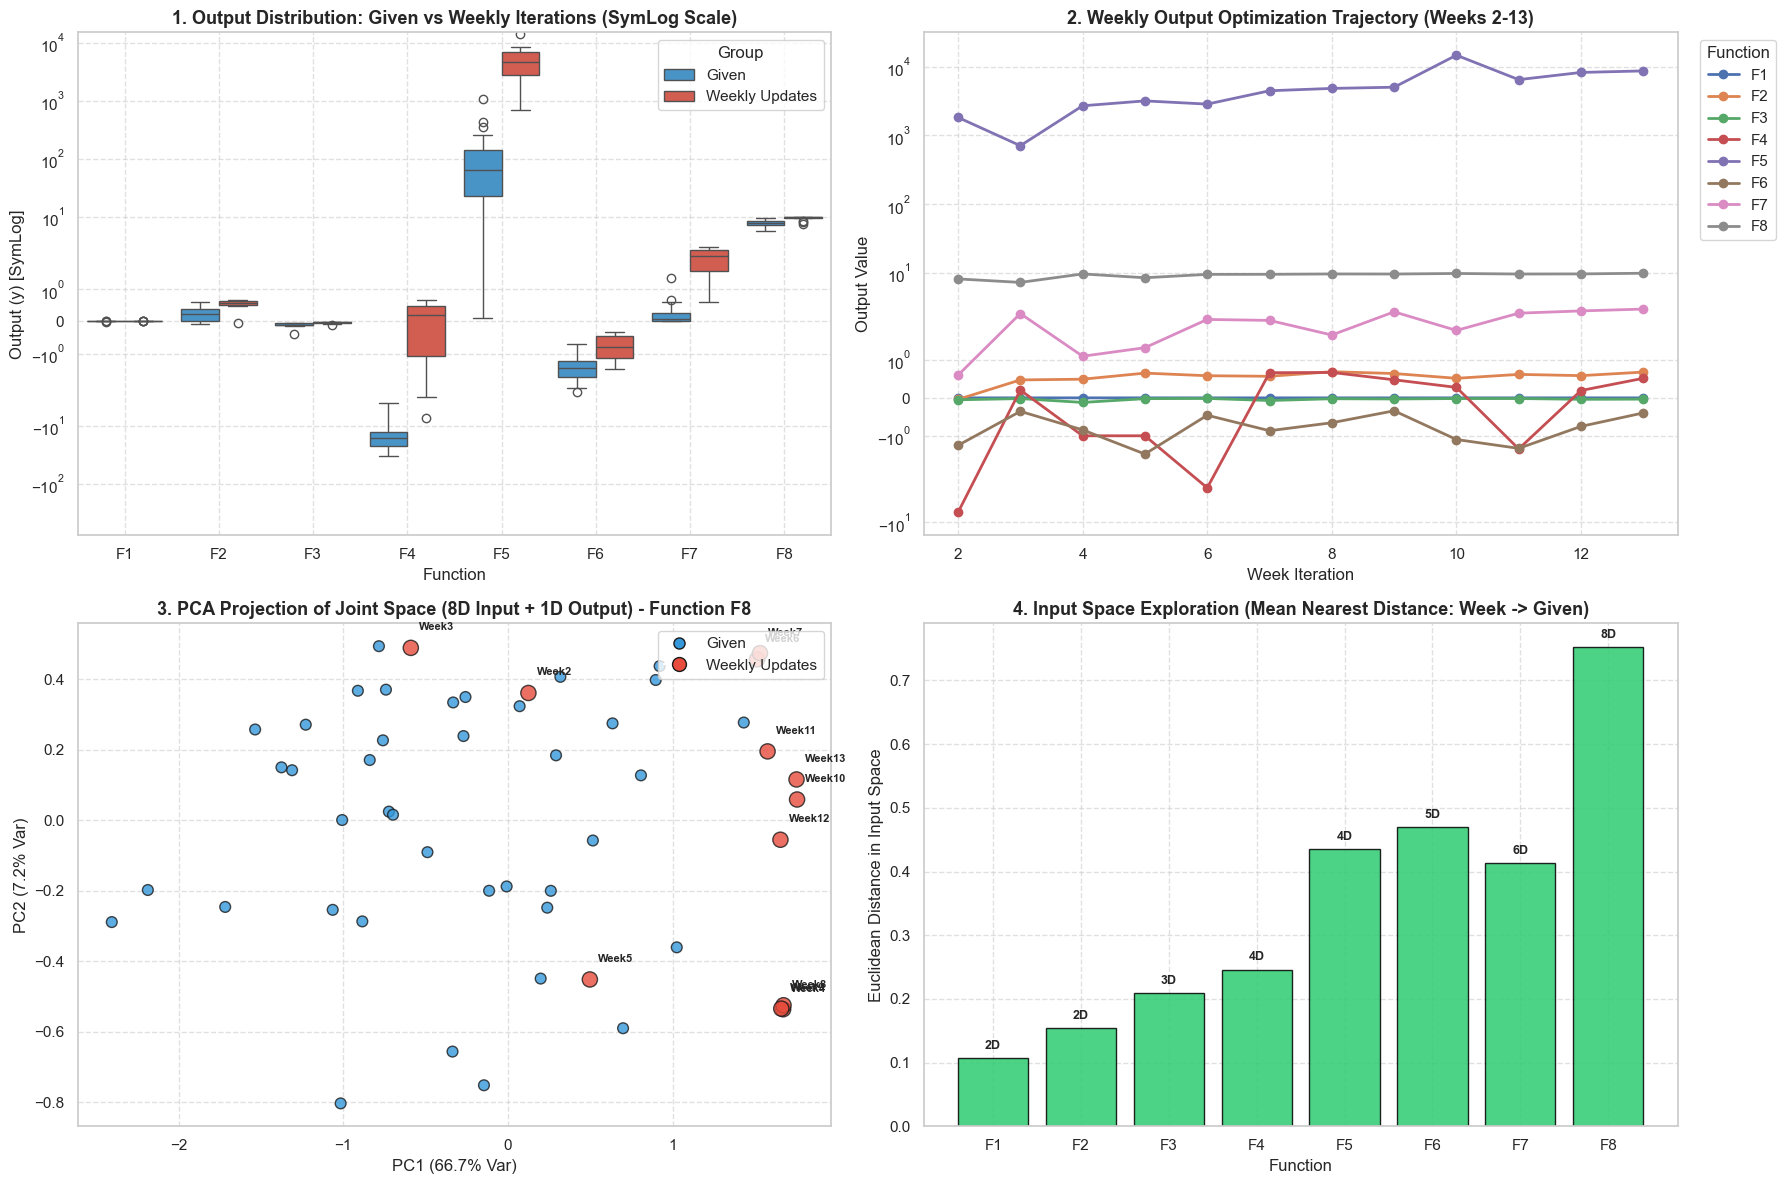

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Set style
sns.set_theme(style="whitegrid")

xls = pd.ExcelFile(file_path)

# Create a figure with multiple subplots
fig = plt.figure(figsize=(18, 12))

# -------------------------------------------------------------
# Plot 1: Output Value Distribution across 8 Functions (Given vs Week)
# -------------------------------------------------------------
all_df = []
for sheet in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)
    df['Function'] = sheet
    df['Group'] = df['Reference'].apply(lambda x: 'Given' if x == 'Given' else 'Weekly Updates')
    all_df.append(df)

combined_df = pd.concat(all_df, ignore_index=True)

ax1 = fig.add_subplot(2, 2, 1)
sns.boxplot(data=combined_df, x='Function', y='Output', hue='Group', palette={'Given': '#3498db', 'Weekly Updates': '#e74c3c'}, ax=ax1)
ax1.set_yscale('symlog') # Handles large variance across functions
ax1.set_title("1. Output Distribution: Given vs Weekly Iterations (SymLog Scale)", fontsize=13, fontweight='bold')
ax1.set_ylabel("Output (y) [SymLog]")
ax1.grid(True, linestyle='--', alpha=0.6)

# -------------------------------------------------------------
# Plot 2: Trajectory of Weekly Optimisation Performance (Functions 1 to 8)
# -------------------------------------------------------------
ax2 = fig.add_subplot(2, 2, 2)
for sheet in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)
    weekly = df[df['Reference'] != 'Given'].copy()
    weekly['Week_Num'] = weekly['Reference'].str.extract('(\d+)').astype(int)
    weekly = weekly.sort_values('Week_Num')
    ax2.plot(weekly['Week_Num'], weekly['Output'], marker='o', linewidth=2, label=sheet)

ax2.set_title("2. Weekly Output Optimization Trajectory (Weeks 2-13)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Week Iteration")
ax2.set_ylabel("Output Value")
ax2.set_yscale('symlog')
ax2.legend(title="Function", bbox_to_anchor=(1.02, 1), loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.6)

# -------------------------------------------------------------
# Plot 3: PCA / Projection of High-Dim Search Space (Function 8: 8D)
# -------------------------------------------------------------
df_f8 = pd.read_excel(file_path, sheet_name='F8')
input_cols_f8 = [c for c in df_f8.columns if c.startswith('Input_')]
X_f8 = MinMaxScaler().fit_transform(df_f8[input_cols_f8].values)
y_f8 = StandardScaler().fit_transform(df_f8[['Output']].values)
XY_f8 = np.hstack([X_f8, y_f8])

pca = PCA(n_components=2)
coords = pca.fit_transform(XY_f8)

ax3 = fig.add_subplot(2, 2, 3)
scatter = ax3.scatter(
    coords[:, 0], coords[:, 1], 
    c=['#3498db' if r == 'Given' else '#e74c3c' for r in df_f8['Reference']],
    s=[60 if r == 'Given' else 120 for r in df_f8['Reference']],
    marker='o', edgecolors='k', alpha=0.8
)
# Annotate weekly points
for idx, row in df_f8.iterrows():
    if row['Reference'] != 'Given':
        ax3.annotate(row['Reference'], (coords[idx, 0]+0.05, coords[idx, 1]+0.05), fontsize=8, fontweight='bold')

ax3.set_title("3. PCA Projection of Joint Space (8D Input + 1D Output) - Function F8", fontsize=13, fontweight='bold')
ax3.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Var)")
ax3.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Var)")
ax3.grid(True, linestyle='--', alpha=0.6)

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Given', markerfacecolor='#3498db', markersize=8, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='Weekly Updates', markerfacecolor='#e74c3c', markersize=10, markeredgecolor='k')
]
ax3.legend(handles=legend_elements, loc='upper right')

# -------------------------------------------------------------
# Plot 4: Average Exploration Distance from 'Given' Space
# -------------------------------------------------------------
from scipy.spatial.distance import cdist

avg_distances = []
for sheet in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)
    in_cols = [c for c in df.columns if c.startswith('Input_')]
    
    X_g = df[df['Reference'] == 'Given'][in_cols].values
    X_w = df[df['Reference'] != 'Given'][in_cols].values
    
    # Distance matrix from each week point to closest given point
    min_dists = np.min(cdist(X_w, X_g, metric='euclidean'), axis=1)
    avg_distances.append({
        'Function': sheet,
        'Mean_Dist': np.mean(min_dists),
        'Max_Dist': np.max(min_dists),
        'Dim': len(in_cols)
    })

dist_df = pd.DataFrame(avg_distances)

ax4 = fig.add_subplot(2, 2, 4)
bars = ax4.bar(dist_df['Function'], dist_df['Mean_Dist'], color='#2ecc71', edgecolor='black', alpha=0.85)
ax4.set_title("4. Input Space Exploration (Mean Nearest Distance: Week -> Given)", fontsize=13, fontweight='bold')
ax4.set_xlabel("Function")
ax4.set_ylabel("Euclidean Distance in Input Space")
ax4.grid(True, linestyle='--', alpha=0.6)

# Annotate dimension above bars
for bar, dim in zip(bars, dist_df['Dim']):
    yval = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f"{dim}D", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
#plt.savefig('final-initial-vs-queries.png', dpi=1200)
plt.show()

In [4]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


xls = pd.ExcelFile(file_path)

results = []

for sheet in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)
    input_cols = [c for c in df.columns if c.startswith('Input_')]
    dim = len(input_cols)
    
    # Split into Before (Given only) and After (Given + Weekly)
    df_before = df[df['Reference'] == 'Given'].copy()
    df_after = df.copy()
    
    # Helper to process and compute metrics
    def evaluate_clustering(sub_df, k=2):
        X = sub_df[input_cols].values
        y = sub_df['Output'].values.reshape(-1, 1)
        
        # Scaling inputs [0,1] and outputs Z-score
        X_scaled = MinMaxScaler().fit_transform(X)
        y_scaled = StandardScaler().fit_transform(y)
        XY = np.hstack([X_scaled, y_scaled])
        
        if len(sub_df) <= k:
            return None, None, None
            
        km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(XY)
        labels = km.labels_
        
        if len(np.unique(labels)) < 2:
            return None, None, None
            
        sil = silhouette_score(XY, labels)
        db = davies_bouldin_score(XY, labels)
        ch = calinski_harabasz_score(XY, labels)
        return sil, db, ch

    # Evaluate K=2 and K=3
    for k in [2, 3]:
        sil_b, db_b, ch_b = evaluate_clustering(df_before, k=k)
        sil_a, db_a, ch_a = evaluate_clustering(df_after, k=k)
        
        results.append({
            'Function': sheet,
            'Dimension': dim,
            'N_Before': len(df_before),
            'N_After': len(df_after),
            'K': k,
            'Sil_Before': round(sil_b, 4) if sil_b is not None else np.nan,
            'Sil_After': round(sil_a, 4) if sil_a is not None else np.nan,
            'Sil_Change': round(sil_a - sil_b, 4) if (sil_a is not None and sil_b is not None) else np.nan,
            'DB_Before': round(db_b, 4) if db_b is not None else np.nan,
            'DB_After': round(db_a, 4) if db_a is not None else np.nan,
            'DB_Change': round(db_a - db_b, 4) if (db_a is not None and db_b is not None) else np.nan,
        })

res_df = pd.DataFrame(results)
print(res_df.to_string())

   Function  Dimension  N_Before  N_After  K  Sil_Before  Sil_After  Sil_Change  DB_Before  DB_After  DB_Change
0        F1          2        10       22  2      0.7207     0.8642      0.1435     0.1432    0.0682    -0.0749
1        F1          2        10       22  3      0.4122     0.5017      0.0895     0.5066    0.4394    -0.0672
2        F2          2        10       22  2      0.4669     0.6092      0.1424     0.6606    0.5556    -0.1050
3        F2          2        10       22  3      0.4106     0.4727      0.0621     0.6855    0.7098     0.0243
4        F3          3        15       27  2      0.7144     0.7767      0.0623     0.1617    0.1397    -0.0220
5        F3          3        15       27  3      0.2723     0.4826      0.2103     0.8767    0.5825    -0.2942
6        F4          4        30       42  2      0.4961     0.4552     -0.0410     0.7002    0.7149     0.0147
7        F4          4        30       42  3      0.3322     0.4720      0.1398     1.0484    0.8073    

## Silhouette Score
#### a. Optimal Partitioning (`K = 2` vs. `K = 3`)

* **Macro-Binary Structure (`K = 2` Superiority):** Across almost all functions (except F4 post-optimization), `K = 2` achieves substantially higher Silhouette scores than `K = 3`. This indicates that the input-output space naturally partitions into **two dominant regimes**: baseline search regions (moderate/low output) and specialized optimized regions (high output).
* **Over-Segmentation (`K = 3` Sub-optimality):** Increasing the number of clusters to `K = 3` consistently reduces the Silhouette score across both low- and high-dimensional functions (e.g., F1 drops from 0.8642 to 0.5017). Forcing three clusters splits continuous optimization paths into arbitrary sub-groups with overlapping boundaries.

#### b. Structural Impact of Weekly Optimization (Before vs. After)

* **Cluster Sharpness Increases:** For 6 out of 8 functions under `K = 2` (F1, F2, F3, F6, F7, F8), adding weekly optimization points **increases** the Silhouette score. As the algorithm moves away from baseline points and converges on local optima, it forms dense, distinct clusters with significantly higher output values, accentuating inter-cluster variance.
* **Continuous Trajectory Smoothing (F4 & F5 `K = 2` Anomalies):** In F4 and F5 under `K = 2`, the Silhouette score decreases post-optimization (e.g., F5 drops from 0.6912 to 0.5725). This occurs because weekly iterations create a continuous path across the input domain rather than abrupt jumps, populating intermediate spaces and blurring rigid cluster boundaries.

#### c. Dimensionality Degradation (`2D → 8D`)

* **High Contrast in Low Dimensions:** Functions operating in 2D and 3D space (`F1`–`F3`) exhibit high Silhouette scores (> 0.60–0.86 for `K = 2`). Distance metrics are highly effective here, allowing clear distinction between unexplored domain bounds and optimal clusters.
* **Curse of Dimensionality:** Higher-dimensional functions (`F6` 5D, `F7` 6D, `F8` 8D) show low overall Silhouette scores (0.26–0.51). As dimensionality increases, points become increasingly equidistant in hyperspace, diluting Euclidean distance differences in `K`-Means and resulting in looser, less well-defined clusters.


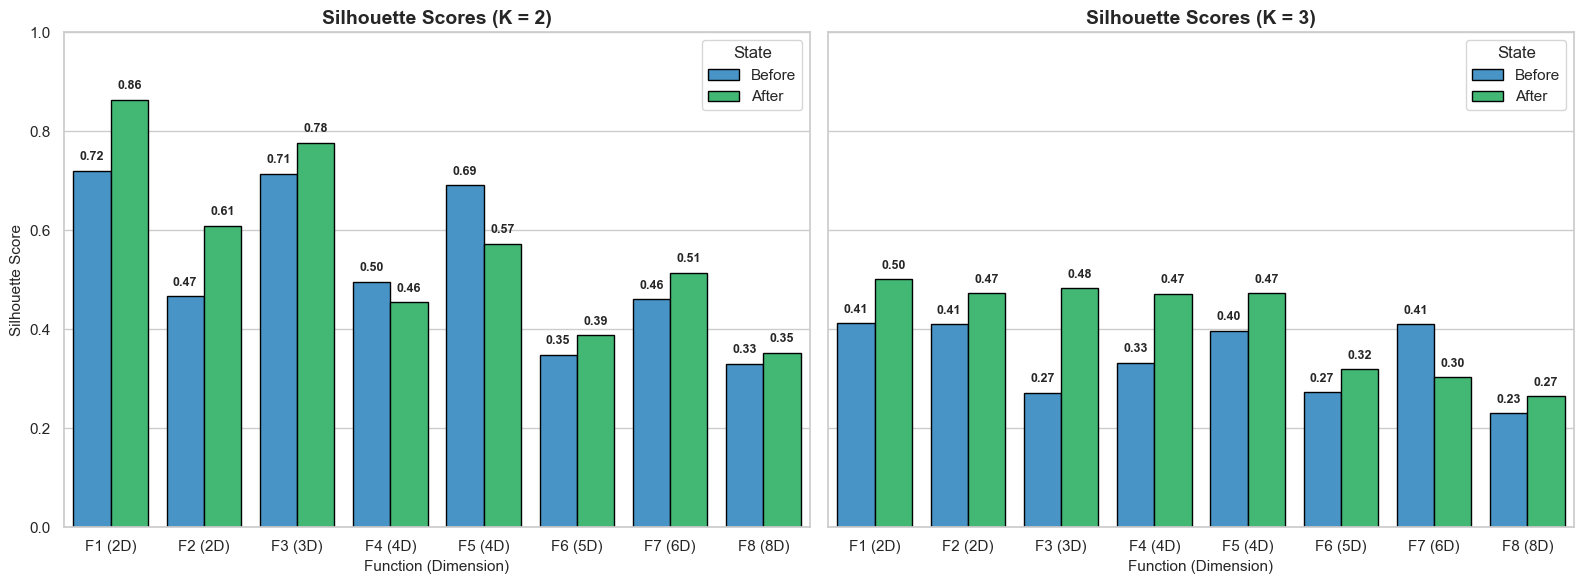

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load dataset
xls = pd.ExcelFile(file_path)

results = []

# Process each function sheet
for sheet in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)
    input_cols = [c for c in df.columns if c.startswith('Input_')]
    dim = len(input_cols)
    
    # Split into 'Before' (Given points) and 'After' (Given + Weekly points)
    df_before = df[df['Reference'] == 'Given'].copy()
    df_after = df.copy()
    
    def compute_silhouette(sub_df, k):
        X = sub_df[input_cols].values
        y = sub_df['Output'].values.reshape(-1, 1)
        
        # Scale inputs to [0,1] and output to unit variance
        X_scaled = MinMaxScaler().fit_transform(X)
        y_scaled = StandardScaler().fit_transform(y)
        XY = np.hstack([X_scaled, y_scaled])
        
        km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(XY)
        return silhouette_score(XY, km.labels_)

    for k in [2, 3]:
        sil_b = compute_silhouette(df_before, k=k)
        sil_a = compute_silhouette(df_after, k=k)
        results.append({
            'Function': sheet,
            'Dimension': f"{sheet} ({dim}D)",
            'K': f"K = {k}",
            'Before': sil_b,
            'After': sil_a
        })

plot_df = pd.DataFrame(results)

# Configure plot layout
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for idx, k_val in enumerate(['K = 2', 'K = 3']):
    sub_df = plot_df[plot_df['K'] == k_val].melt(
        id_vars=['Dimension'], 
        value_vars=['Before', 'After'], 
        var_name='State', 
        value_name='Silhouette Score'
    )
    
    ax = axes[idx]
    sns.barplot(
        data=sub_df, 
        x='Dimension', 
        y='Silhouette Score', 
        hue='State', 
        palette=['#3498db', '#2ecc71'], 
        ax=ax, 
        edgecolor='black'
    )
    
    ax.set_title(f'Silhouette Scores ({k_val})', fontsize=14, fontweight='bold')
    ax.set_xlabel('Function (Dimension)', fontsize=11)
    if idx == 0:
        ax.set_ylabel('Silhouette Score', fontsize=11)
    ax.set_ylim(0, 1.0)
    
    # Add numerical value annotations on top of bars
    for p in ax.patches:
        h = p.get_height()
        if not np.isnan(h) and h > 0:
            ax.annotate(
                f'{h:.2f}', 
                (p.get_x() + p.get_width() / 2., h + 0.015),
                ha='center', va='bottom', fontsize=9, fontweight='bold'
            )

plt.tight_layout()
#plt.savefig('final-silhouette-score.png', dpi=600)
plt.show()

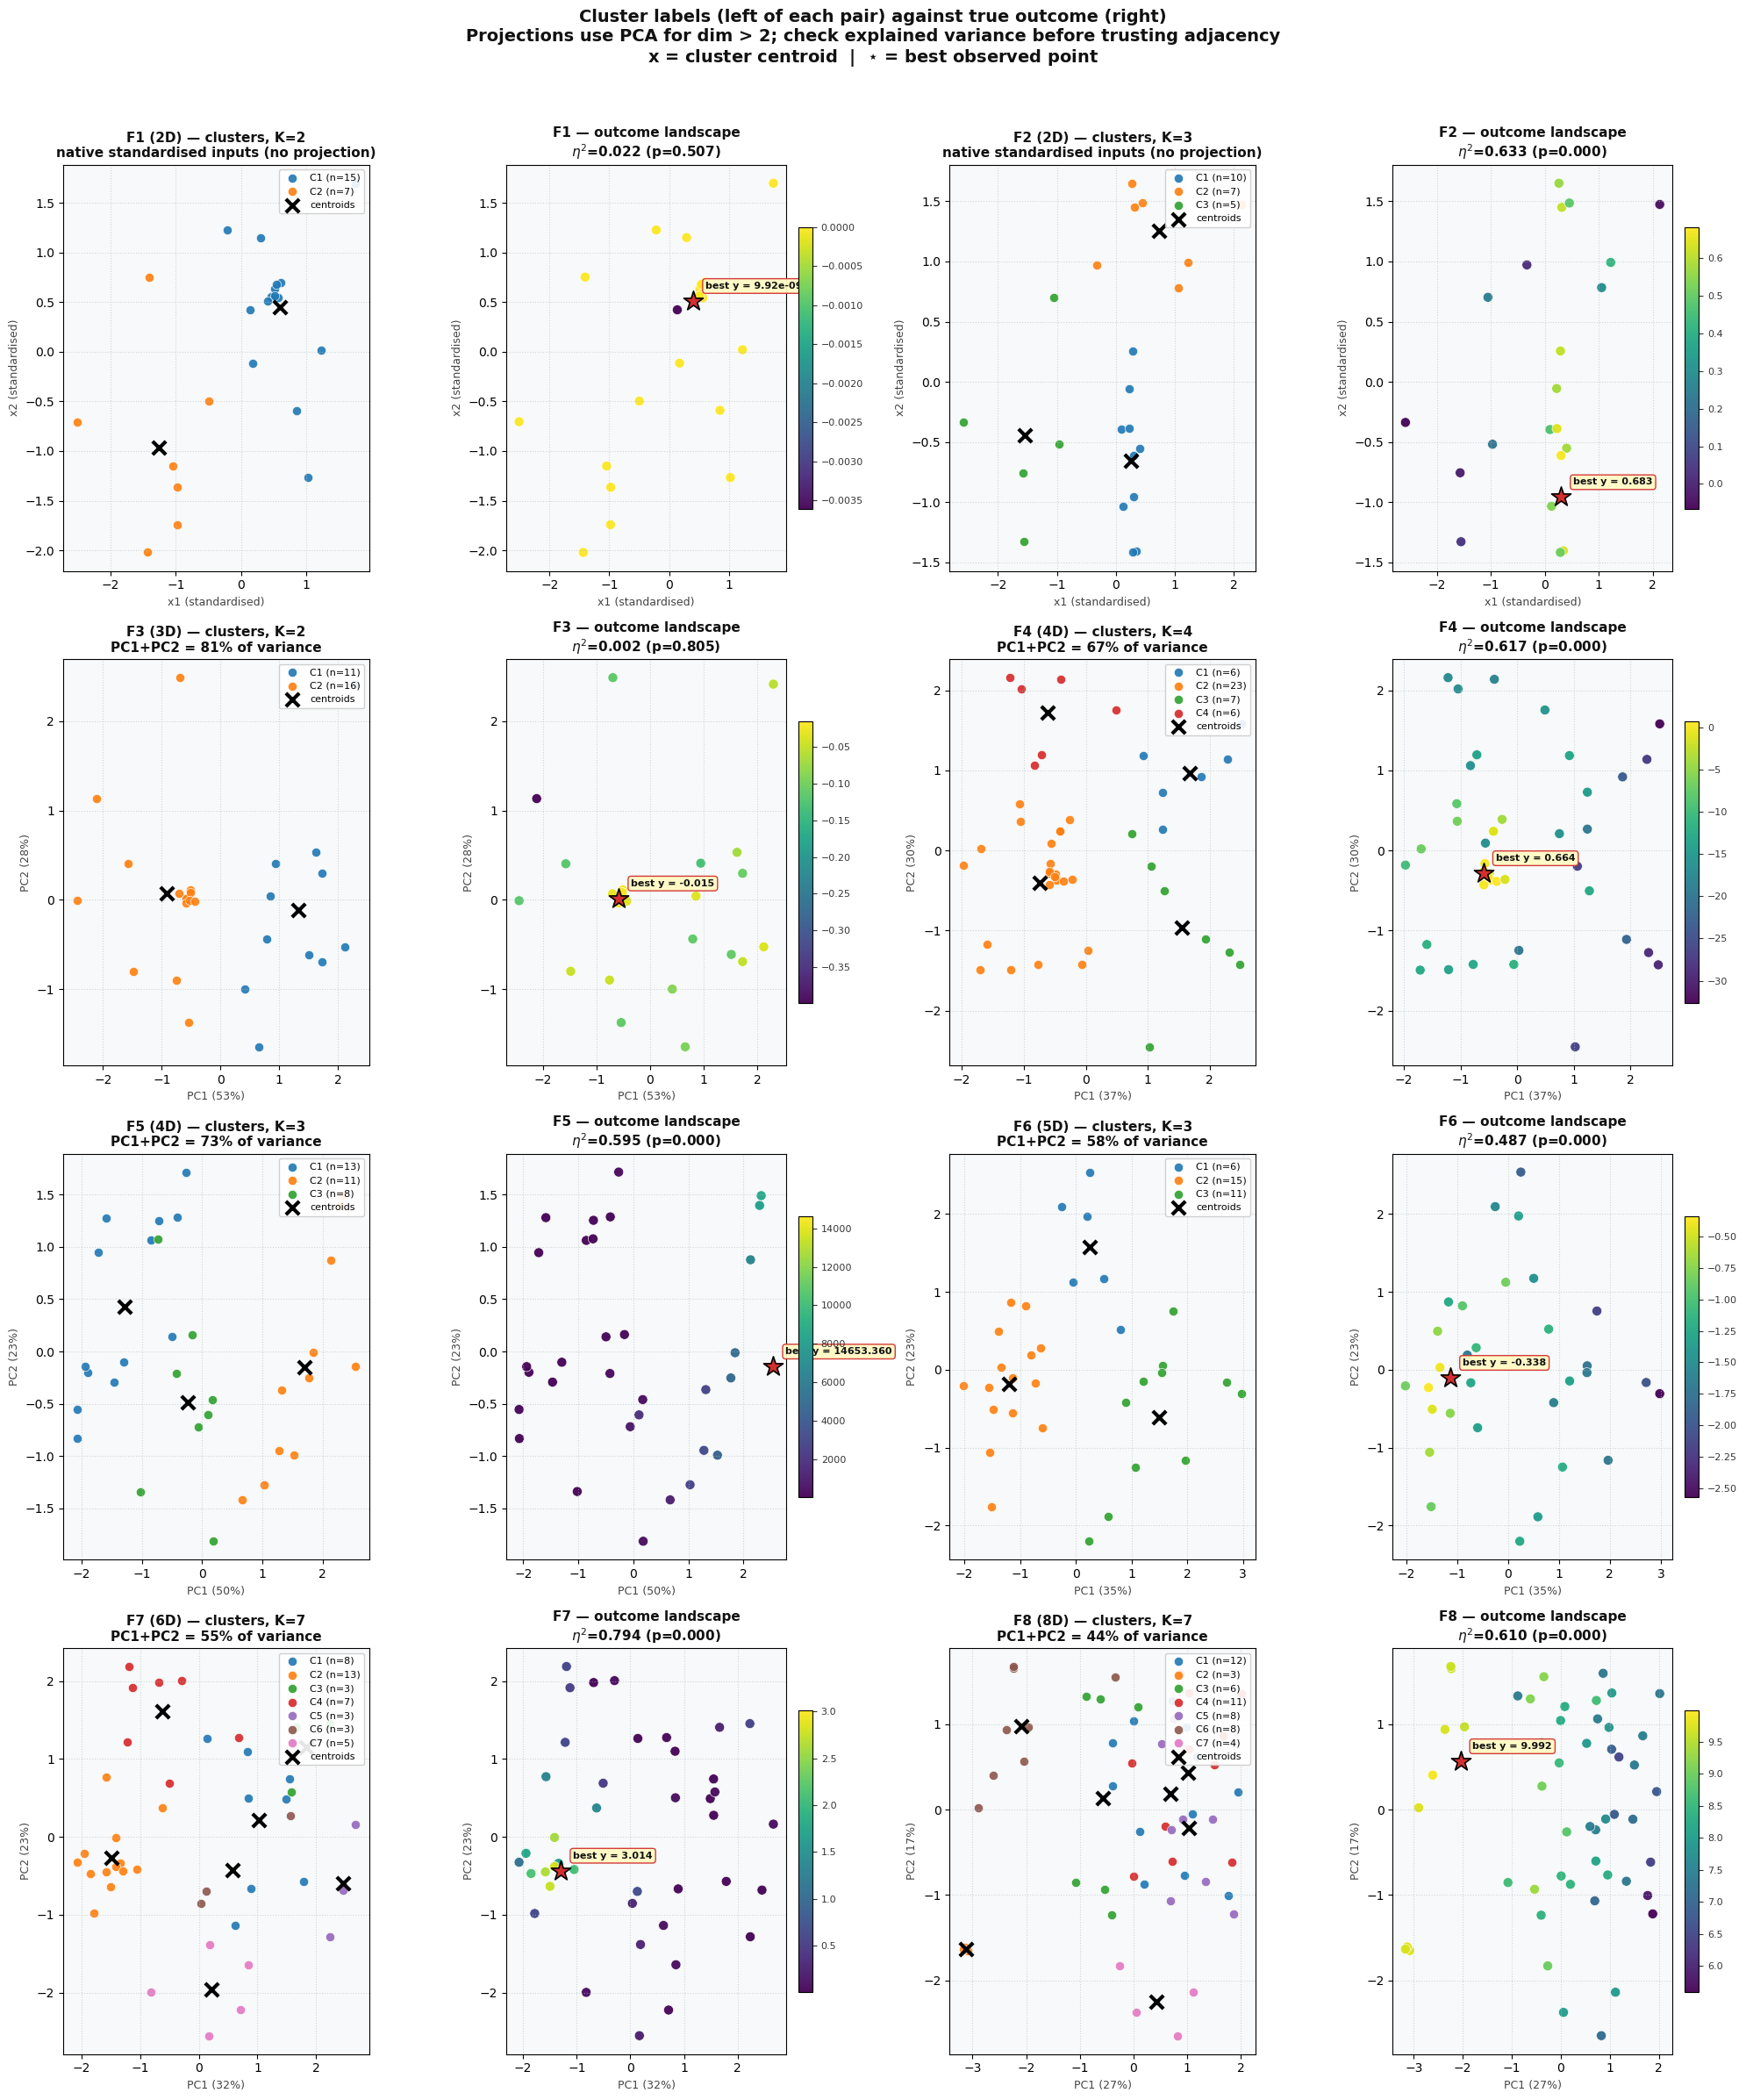

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load Excel Data
xls = pd.ExcelFile(file_path)

# Configuration mapping
k_dict = {
    "F1": 2,
    "F2": 3,
    "F3": 2,
    "F4": 4,
    "F5": 3,
    "F6": 3,
    "F7": 7,
    "F8": 7,
}

# Filter sheets present in both k_dict and the Excel file (up to 8 functions max for 4x4 grid)
target_sheets = [s for s in xls.sheet_names if s in k_dict][:8]

# Set clean light theme and figure background
plt.style.use("default")
fig, axes = plt.subplots(4, 4, figsize=(20, 24), facecolor="#FFFFFF")

# Dynamic high-contrast colormap generator for clusters
cmap_clusters = plt.cm.tab10

for idx, sheet in enumerate(target_sheets):
    row = idx // 2
    col_offset = (idx % 2) * 2

    ax_left = axes[row, col_offset]
    ax_right = axes[row, col_offset + 1]

    # Light grey axes background for subtle framing contrast
    ax_left.set_facecolor("#F8F9FA")
    ax_right.set_facecolor("#F8F9FA")

    # Load sheet data
    df = pd.read_excel(xls, sheet_name=sheet)
    in_cols = [c for c in df.columns if c.startswith("Input_")]
    dim = len(in_cols)
    X = df[in_cols].values
    y = df["Output"].values

    # Standardize inputs
    X_std = StandardScaler().fit_transform(X)

    # PCA projection or native coordinates
    if dim == 2:
        coords = X_std
        xlabel, ylabel = "x1 (standardised)", "x2 (standardised)"
        proj_str = "native standardised inputs (no projection)"
        pca_model = None
    else:
        pca_model = PCA(n_components=2)
        coords = pca_model.fit_transform(X_std)
        var_pct1 = int(round(pca_model.explained_variance_ratio_[0] * 100))
        var_pct2 = int(round(pca_model.explained_variance_ratio_[1] * 100))
        xlabel = f"PC1 ({var_pct1}%)"
        ylabel = f"PC2 ({var_pct2}%)"
        proj_str = f"PC1+PC2 = {var_pct1 + var_pct2}% of variance"

    # Perform Clustering
    k = k_dict[sheet]
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_std)

    # Project true high-dimensional centroids into 2D space
    if dim == 2:
        centroids = km.cluster_centers_
    else:
        centroids = pca_model.transform(km.cluster_centers_)

    # Calculate ANOVA Eta-squared (eta^2) & p-value
    groups = [y[labels == c] for c in range(k) if np.sum(labels == c) > 0]
    if len(groups) > 1 and all(len(g) > 1 for g in groups):
        f_val, p_val = stats.f_oneway(*groups)
        ss_total = np.sum((y - np.mean(y)) ** 2)
        ss_between = np.sum(
            [len(g) * (np.mean(g) - np.mean(y)) ** 2 for g in groups]
        )
        eta_sq = ss_between / ss_total if ss_total > 0 else 0.0
    else:
        eta_sq, p_val = 0.0, 1.0

    # Best observed point (maximization)
    best_idx = np.argmax(y)
    best_y = y[best_idx]
    best_coord = coords[best_idx]

    # --- LEFT PANEL: Cluster Assignments ---
    for c in range(k):
        mask = labels == c
        color = cmap_clusters(c % 10)
        ax_left.scatter(
            coords[mask, 0],
            coords[mask, 1],
            color=color,
            label=f"C{c+1} (n={mask.sum()})",
            s=55,
            alpha=0.9,
            edgecolors="white",
            linewidths=0.5,
        )

    # Centroids drawn in bold black for stark contrast on light background
    ax_left.scatter(
        centroids[:, 0],
        centroids[:, 1],
        c="black",
        marker="x",
        s=120,
        linewidths=3,
        label="centroids",
        zorder=5,
    )
    ax_left.set_title(
        f"{sheet} ({dim}D) — clusters, K={k}\n{proj_str}",
        fontsize=11,
        fontweight="bold",
        color="#111111",
    )
    ax_left.set_xlabel(xlabel, fontsize=9, color="#444444")
    ax_left.set_ylabel(ylabel, fontsize=9, color="#444444")
    ax_left.legend(
        loc="upper right",
        fontsize=8,
        framealpha=0.9,
        facecolor="white",
        edgecolor="#CCCCCC",
    )
    ax_left.grid(True, linestyle=":", alpha=0.6, color="#B0BEC5")

    # --- RIGHT PANEL: Outcome Heatmap (True y) ---
    sc = ax_right.scatter(
        coords[:, 0],
        coords[:, 1],
        c=y,
        cmap="viridis",
        s=65,
        alpha=0.95,
        edgecolors="white",
        linewidths=0.5,
    )
    cbar = fig.colorbar(sc, ax=ax_right, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8, colors="#333333")

    # Highlight best observed point with vibrant crimson star
    ax_right.scatter(
        best_coord[0],
        best_coord[1],
        c="#D32F2F",
        marker="*",
        s=280,
        edgecolors="black",
        linewidths=1.2,
        zorder=10,
    )

    best_str = (
        f"best y = {best_y:.3f}"
        if abs(best_y) > 0.001
        else f"best y = {best_y:.2e}"
    )
    ax_right.annotate(
        best_str,
        (best_coord[0], best_coord[1]),
        xytext=(10, 10),
        textcoords="offset points",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="#FFF9C4",
            alpha=0.95,
            edgecolor="#D32F2F",
        ),
        fontsize=8,
        color="#111111",
        fontweight="bold",
    )

    ax_right.set_title(
        f"{sheet} — outcome landscape\n$\\eta^2$={eta_sq:.3f} (p={p_val:.3f})",
        fontsize=11,
        fontweight="bold",
        color="#111111",
    )
    ax_right.set_xlabel(xlabel, fontsize=9, color="#444444")
    ax_right.set_ylabel(ylabel, fontsize=9, color="#444444")
    ax_right.grid(True, linestyle=":", alpha=0.6, color="#B0BEC5")

# Hide unused axes if fewer than 8 sheets were plotted
total_plotted_axes = len(target_sheets) * 2
for idx in range(total_plotted_axes, 16):
    r = idx // 4
    c = idx % 4
    fig.delaxes(axes[r, c])

# Figure Title
fig.suptitle(
    "Cluster labels (left of each pair) against true outcome (right)\n"
    "Projections use PCA for dim > 2; check explained variance before trusting adjacency\n"
    "x = cluster centroid  |  " + r"$\star$" + " = best observed point",
    fontsize=14,
    fontweight="bold",
    color="#111111",
    y=0.995,
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## 1. Scree plots 

#### a. Sharp "Elbow" in Low-Dimensional Functions (`F1`–`F3`)

* **Dominant First Component:** In `F1` and `F2`, **PC1 captures 76.31% and 69.39%** of the total variance, respectively.
* **Clear Knee/Elbow Point:** The scree curve drops off sharply after PC1. A 2D projection preserves 100% of the variance without any loss of structural information.
* **`F3` (3D Space):** Displays a steep initial decline, with PC1 (52.75%) and PC2 (27.57%) capturing **80.31%** of the total variance, leaving PC3 with under 20%.

#### b. Flattening Scree Curves in High-Dimensional Spaces (`F6`–`F8`)

* **Distributed Variance:** As input dimensionality grows to 5D (`F6`), 6D (`F7`), and 8D (`F8`), the scree plots flatten out significantly.
* **No Single Dominant Component:** In `F8` (8D), PC1 explains only **26.90%** of the variance, followed closely by PC2 (16.53%), PC3 (14.53%), and PC4 (11.54%).
* **Orthogonal Spread:** The variance is widely distributed across almost all components rather than concentrated in the first one or two, indicating a complex, multi-directional search space.

#### c. Fidelity of 2D Projections for Optimisation Trajectories

* **High-Fidelity Visuals (`F1`–`F5`):** 2D scatter plot retention ranges from **66.88% (`F4`) to 100% (`F1`)**, making 2D PCA plots reliable for evaluating trajectory distances and spatial clusters.
* **Information Loss in 2D (`F7` & `F8`):** A 2D projection retains only **54.25% (`F7`)** and **43.42% (`F8`)** of the total variance. While 2D plots for `F8` capture broad directional trends, more than half of the spatial variance resides in higher components (PC3–PC8), requiring caution when interpreting point proximity in 2D projections.


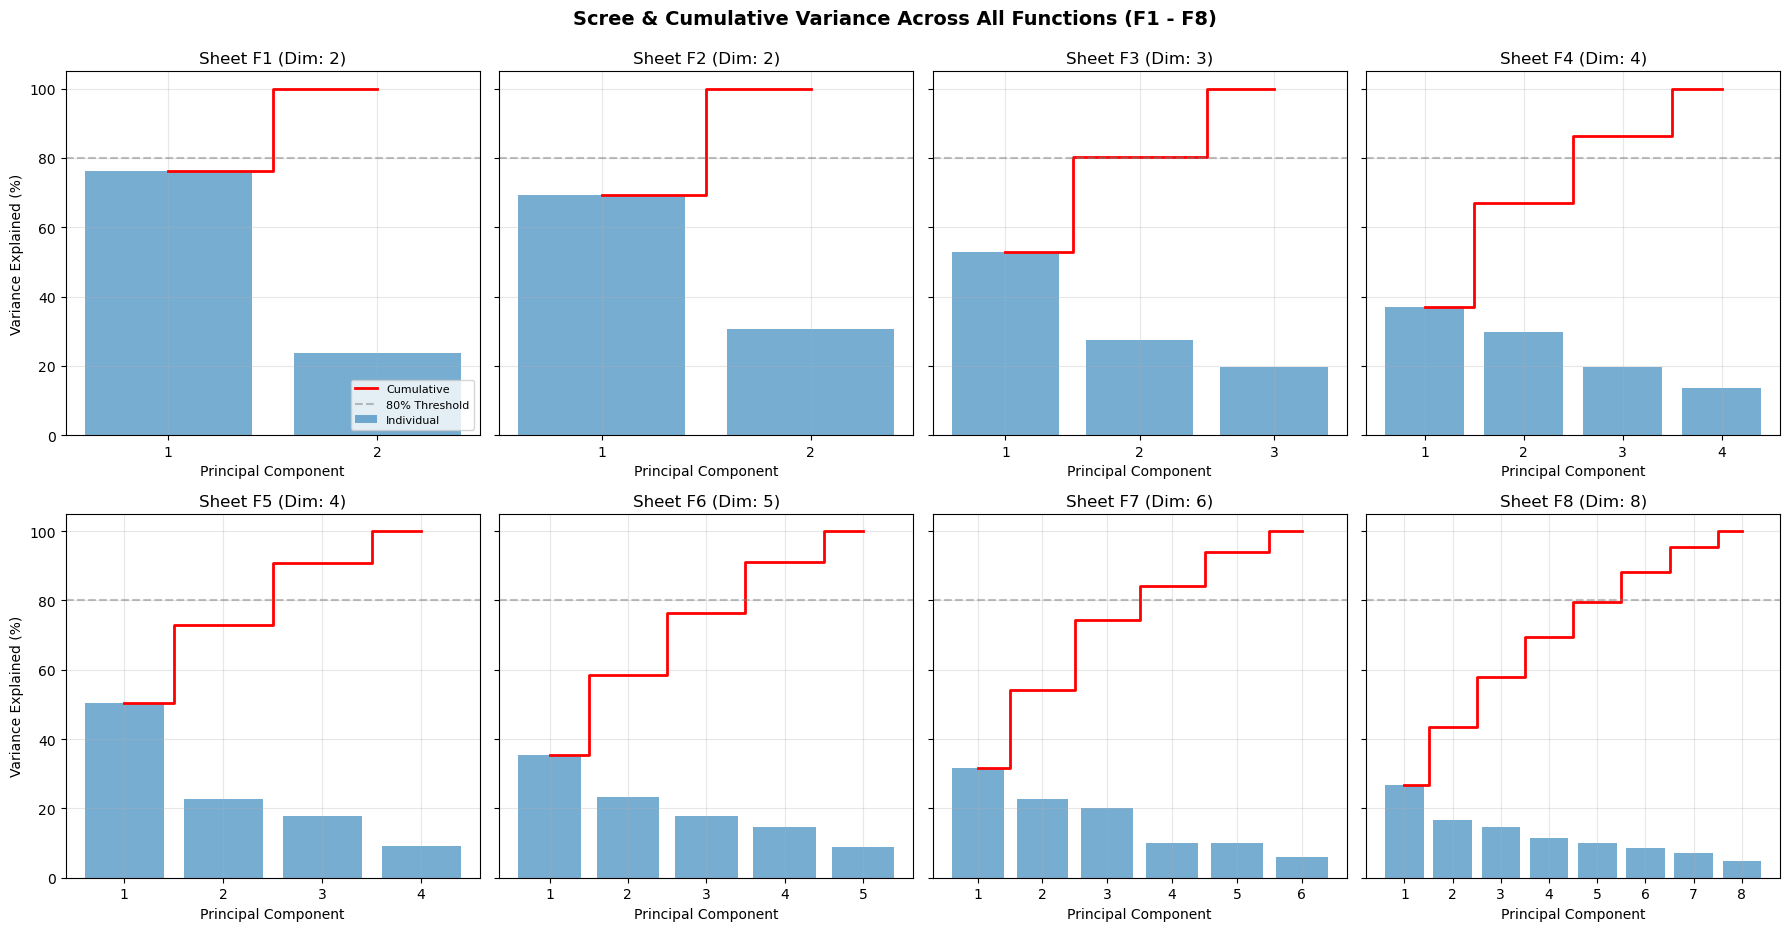

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load the workbook
xls = pd.ExcelFile(file_path)

# 2. Set up a multi-panel subplot grid (2 rows, 4 columns for 8 sheets)
fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharey=True)
axes = axes.flatten()

for idx, sheet in enumerate(xls.sheet_names):
    # Read sheet and extract input features (excluding Output and Reference)
    df = pd.read_excel(file_path, sheet_name=sheet)
    inputs = df.drop(columns=[c for c in ['Output', 'Reference'] if c in df.columns])
    
    # Standardize data to give all variables equal variance
    scaler = StandardScaler()
    scaled_inputs = scaler.fit_transform(inputs)
    
    # Fit PCA
    pca = PCA()
    pca.fit(scaled_inputs)
    
    # Calculate metrics
    individual_variance = pca.explained_variance_ratio_ * 100
    cumulative_variance = np.cumsum(individual_variance)
    components = np.arange(1, len(individual_variance) + 1)
    
    # Plot Scree (Individual Variance as Bars)
    ax = axes[idx]
    ax.bar(components, individual_variance, alpha=0.6, align='center', label='Individual')
    
    # Plot Cumulative Variance as a Line
    ax.step(components, cumulative_variance, where='mid', label='Cumulative', color='red', linewidth=2)
    ax.axhline(y=80, color='gray', linestyle='--', alpha=0.5, label='80% Threshold')
    
    ax.set_title(f'Sheet {sheet} (Dim: {inputs.shape[1]})')
    ax.set_xlabel('Principal Component')
    if idx % 4 == 0:
        ax.set_ylabel('Variance Explained (%)')
    ax.set_xticks(components)
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.suptitle('Scree & Cumulative Variance Across All Functions (F1 - F8)', y=1.03, fontsize=14, fontweight='bold')
#plt.savefig('final-scree-plot.png', dpi=600)
plt.show()

## 2. 2D/3D Scatter Plots (PC1, PC2, PC3)

#### a. Spatial Output Gradients vs. Output Clustering

* **Low-Dimensional Regularity (`F1`–`F3`):** In 2D and 3D functions, the output values form smooth, continuous colour gradients across the PC1 vs. PC2 plane. High output values (represented by brighter/yellow markers in the Viridis palette) concentrate along distinct edges or corners of the principal component space, showing clear directional paths for optimiser convergence.
* **High-Dimensional Dispersion (`F6`–`F8`):** As dimensionality increases, high-output points appear more scattered in a 2D projection. This visual mixing occurs because a 2D scatter captures only **58.55% (`F6`)**, **54.25% (`F7`)**, and **43.42% (`F8`)** of the total input variance, meaning high-performing points may be separated along higher components (such as PC3 or PC4).

#### b. The Role of the Third Principal Component (PC3)

* **Essential for Medium Dimensions (`F3`–`F5`):** Adding PC3 increases captured variance significantly: `F3` reaches **100.00%**, `F4` reaches **86.47%**, and `F5` reaches **90.79%**. In 3D scatter plots (PC1, PC2, PC3), points that overlap in 2D separate along PC3, revealing that optimal regions often lie in narrow 3D tunnels or pockets rather than broad planar surfaces.
* **Partial Relief in High Dimensions (`F6`–`F7`):** Moving from 2D to 3D raises explained variance in `F6` and `F7` from approximately **55% to approximately 75%**, resolving much of the visual overlap and revealing cleaner trajectories toward high-output regions.

#### c. Optimiser Behaviour in Projected Space

* **Exploration Bounds:** Baseline `Given` points spread across the outer perimeter of the PC scatter space.
* **Exploitation Focus:** Weekly optimisation iterations move toward dense, localised clusters near high-output regions along PC1 and PC2, confirming that black-box optimisation effectively navigates the principal directions of the design space.

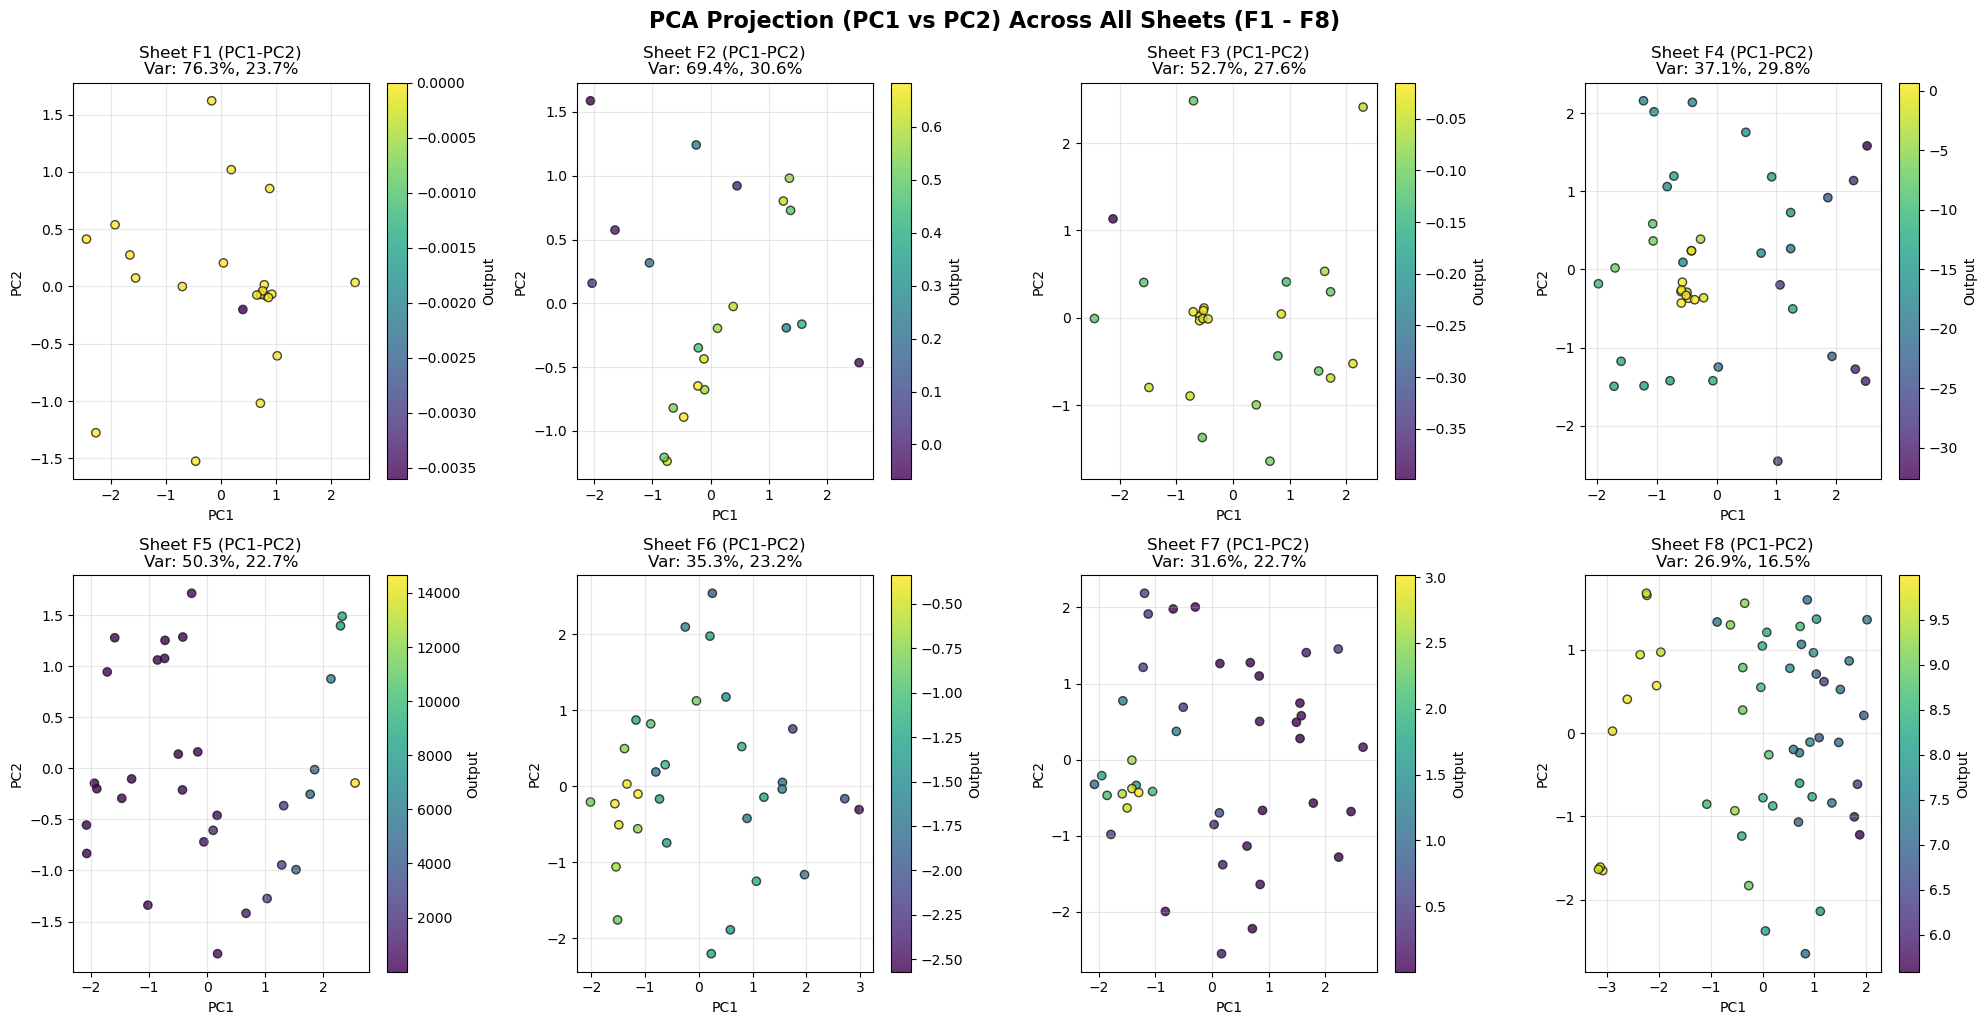

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

xls = pd.ExcelFile(file_path)

# Let's generate scatter plots of PC1 vs PC2 (and PC3 where applicable) for sheets with >= 3 dimensions or all sheets
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, sheet in enumerate(xls.sheet_names):
    df = pd.read_excel(file_path, sheet_name=sheet)
    inputs = df.drop(columns=[c for c in ['Output', 'Reference'] if c in df.columns])
    
    scaler = StandardScaler()
    scaled = scaler.fit_transform(inputs)
    
    pca = PCA(n_components=min(2, inputs.shape[1]))
    pca_coords = pca.fit_transform(scaled)
    
    ax = axes[idx]
    # Color points by Output value
    scatter = ax.scatter(pca_coords[:, 0], pca_coords[:, 1], c=df['Output'], cmap='viridis', edgecolors='k', alpha=0.8)
    
    ev_ratio = pca.explained_variance_ratio_ * 100
    ax.set_title(f'Sheet {sheet} (PC1-PC2)\nVar: {ev_ratio[0]:.1f}%, {ev_ratio[1] if len(ev_ratio)>1 else 0:.1f}%')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.3)
    fig.colorbar(scatter, ax=ax, label='Output')

plt.tight_layout()
plt.suptitle('PCA Projection (PC1 vs PC2) Across All Sheets (F1 - F8)', y=1.02, fontsize=16, fontweight='bold')
#plt.savefig('final-scatter-plot.png', dpi=1200)
plt.show()

## 3. Scree Plots

#### a. Low Dimensions (`F1`–`F3`): Steep Drop-offs and High Compressibility

* **Dominant Primary Component:** In `F1` and `F2`, **PC1 captures 76.31% and 69.39%** of the total variance, respectively. The scree plots exhibit a sharp, clear elbow around PC2.
* **High Information Retention:** In `F3` (3D space), PC1 (52.75%) and PC2 (27.57%) account for **80.31%** of the total variance. The steep drop between PC1 and PC3 indicates that the input domain's principal orientation lies along a primary 2D subspace.

#### b. High Dimensions (`F6`–`F8`): Flattened Curves and Distributed Variance

* **Absence of a Singular Dominant Axis:** As the input dimensionality increases to 5D (`F6`), 6D (`F7`), and 8D (`F8`), the scree plots flatten substantially. In `F8`, PC1 accounts for only **26.90%** of the variance, with PC2 (16.53%), PC3 (14.53%), and PC4 (11.54%) contributing nearly equal shares.
* **Multi-Directional Dispersion:** The absence of a prominent elbow indicates that variance is broadly spread across orthogonal axes in high-dimensional hyperspace rather than concentrated along a dominant trajectory.

#### c. Guidance for Dimensionality Reduction Fidelity

* **2D Projections (`F1`–`F5`):** For functions up to 4D (`F1`–`F5`), a 2D projection preserves between **66.88% (`F4`) and 100.00% (`F1`)** of the structural variation, making 2D spatial analysis highly reliable.
* **Loss of Information in High Dimensions (`F7` & `F8`):** In `F7` (6D) and `F8` (8D), a 2D projection captures only **54.25%** and **43.42%** of the total variance, respectively. Because over half the variance resides in higher-order components (PC3–PC8), 2D plots for these functions should be interpreted as approximate lower-dimensional visual summaries rather than complete representations of spatial proximity.


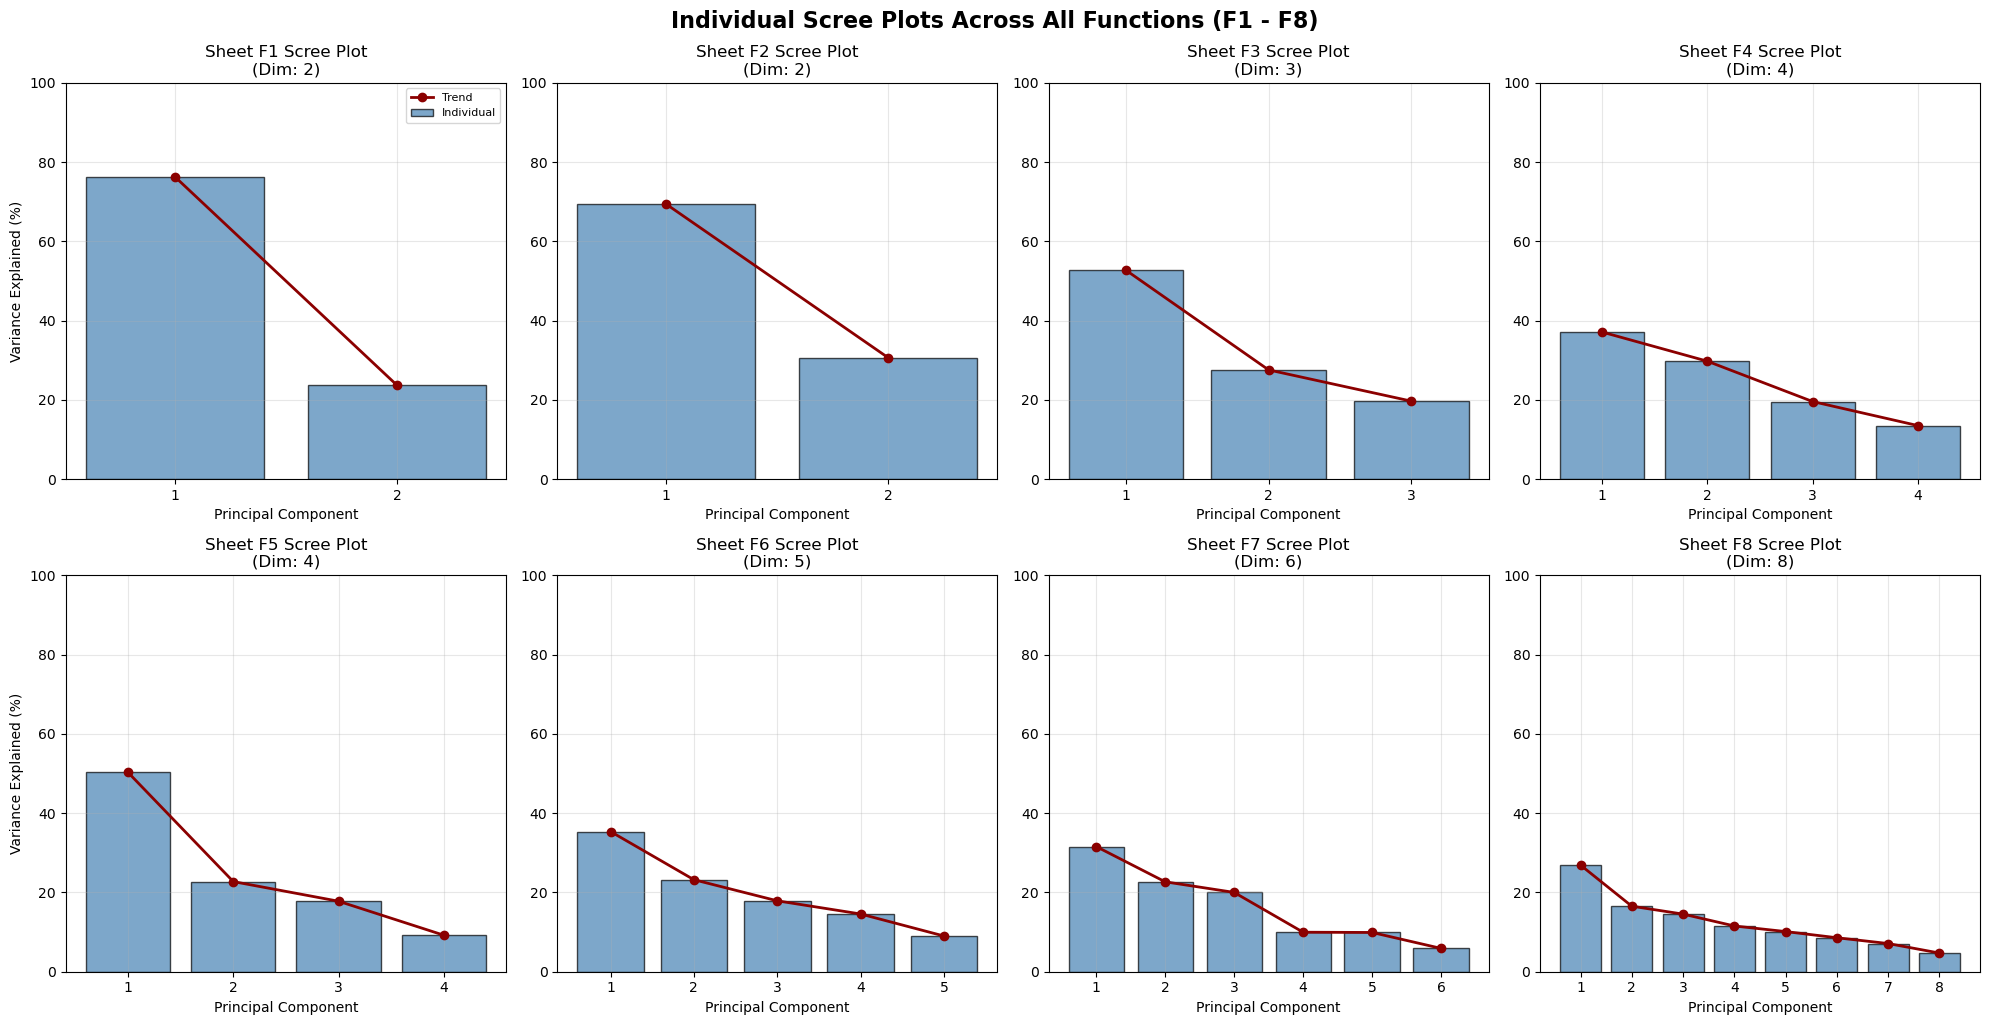

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

xls = pd.ExcelFile(file_path)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, sheet in enumerate(xls.sheet_names):
    df = pd.read_excel(file_path, sheet_name=sheet)
    inputs = df.drop(columns=[c for c in ['Output', 'Reference'] if c in df.columns])
    
    scaler = StandardScaler()
    scaled = scaler.fit_transform(inputs)
    
    pca = PCA()
    pca.fit(scaled)
    
    ind_var = pca.explained_variance_ratio_ * 100
    components = np.arange(1, len(ind_var) + 1)
    
    ax = axes[idx]
    ax.bar(components, ind_var, alpha=0.7, color='steelblue', edgecolor='black', label='Individual')
    ax.plot(components, ind_var, color='darkred', marker='o', linewidth=2, label='Trend')
    
    ax.set_title(f'Sheet {sheet} Scree Plot\n(Dim: {inputs.shape[1]})')
    ax.set_xlabel('Principal Component')
    if idx % 4 == 0:
        ax.set_ylabel('Variance Explained (%)')
    ax.set_xticks(components)
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.suptitle('Individual Scree Plots Across All Functions (F1 - F8)', y=1.02, fontsize=16, fontweight='bold')
#plt.savefig('final-scree-individual-plot.png', dpi=600)
plt.show()

## 4. Cumulative Variance Plots

#### a. Rate of Accumulation (Curve Concavity)

* **High Concavity (`F1`–`F3`):** Lower-dimensional functions show steeply concave cumulative variance curves. The first two components capture **100.00%** of the variance in `F1` and `F2`, and **80.31%** in `F3`. This rapid rise confirms that the design variables in low-dimensional spaces are strongly correlated along dominant principal directions.
* **Linear Accumulation (`F8`):** As input dimensionality reaches 8D (`F8`), the cumulative variance curve approaches a near-linear trajectory. Each component contributes a similar increment (~10% to 15%), reflecting an isotropic distribution of variance where information cannot be easily summarised by a single dominant axis.

#### b. Effective Dimensionality Reduction (`≥ 80%` & `≥ 90%` Thresholds)

* **Significant Subspace Compression (`F3`–`F6`):**

  * In `F3` (3D), **2 components (PC1–PC2)** are sufficient to cross the **80%** threshold.
  * In `F4` and `F5` (4D), **3 components (PC1–PC3)** capture **86.47%** and **90.79%** of the variance, enabling a 25% reduction in dimensions with minimal loss of information.
  * In `F6` (5D), **4 components (PC1–PC4)** capture **90.99%** of the total variance.
* **Diminishing Compression Efficiency (`F7` & `F8`):**

  * In `F7` (6D), reaching **90%** variance requires **5 out of 6 components (PC1–PC5)**.
  * In `F8` (8D), retaining **≥ 80%** variance requires **6 components (PC1–PC6)**, while reaching **≥ 90%** requires **7 components (PC1–PC7)**. High-dimensional functions therefore resist aggressive linear dimensionality reduction.

#### c. Visual & Analytical Fidelity Bounds

* **2D Visual Safety (`F1`–`F3`):** 2D projections preserve **≥ 80%** of the total variance, ensuring that distance metrics and trajectory clusters observed on 2D plots provide a relatively accurate representation of true spatial relationships.
* **3D Visual Requirement (`F4`–`F6`):** A 2D projection retains only **58.55% to 73.01%** of the total variance. Including PC3 raises variance retention to between **76.43% (`F6`) and 90.79% (`F5`)**, making 3D scatter plots preferable for analysing optimisation convergence without substantial distortion.
* **Multivariate Subspace Reliance (`F7` & `F8`):** Because 2D and 3D projections capture only **43.42% to 57.96%** of the variance in `F8`, lower-dimensional visualisations should be treated as partial projections rather than complete representations of search-space behaviour.


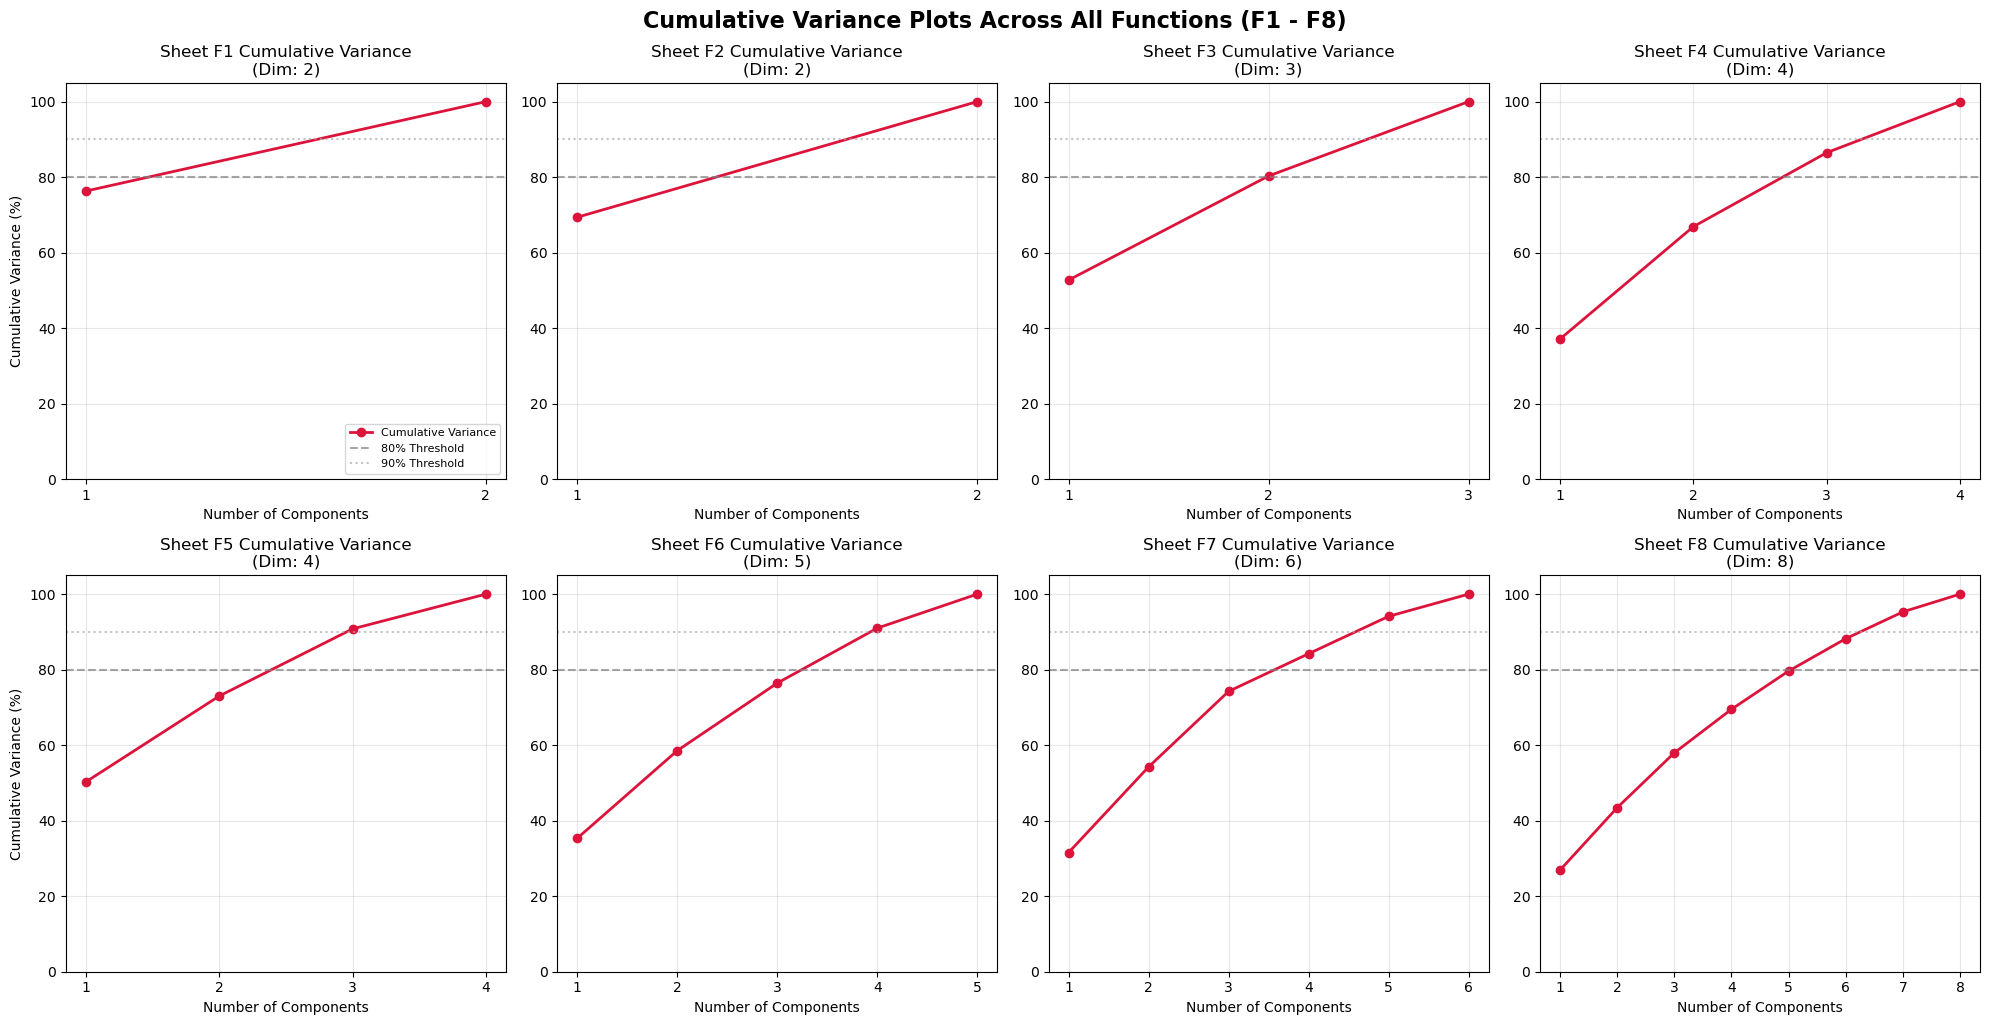

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

xls = pd.ExcelFile(file_path)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, sheet in enumerate(xls.sheet_names):
    df = pd.read_excel(file_path, sheet_name=sheet)
    inputs = df.drop(columns=[c for c in ['Output', 'Reference'] if c in df.columns])
    
    scaler = StandardScaler()
    scaled = scaler.fit_transform(inputs)
    
    pca = PCA()
    pca.fit(scaled)
    
    ind_var = pca.explained_variance_ratio_ * 100
    cum_var = np.cumsum(ind_var)
    components = np.arange(1, len(ind_var) + 1)
    
    ax = axes[idx]
    ax.plot(components, cum_var, color='crimson', marker='o', linewidth=2, label='Cumulative Variance')
    ax.axhline(y=80, color='gray', linestyle='--', alpha=0.7, label='80% Threshold')
    ax.axhline(y=90, color='darkgray', linestyle=':', alpha=0.7, label='90% Threshold')
    
    ax.set_title(f'Sheet {sheet} Cumulative Variance\n(Dim: {inputs.shape[1]})')
    ax.set_xlabel('Number of Components')
    if idx % 4 == 0:
        ax.set_ylabel('Cumulative Variance (%)')
    ax.set_xticks(components)
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.suptitle('Cumulative Variance Plots Across All Functions (F1 - F8)', y=1.02, fontsize=16, fontweight='bold')
#plt.savefig('final-cumulative-variance-plot.png', dpi=600)
plt.show()

## 5. Biplots

#### a. Variable Correlations & Alignment (Vector Angles)

* **Orthogonal Variable Spaces (`F1` & `F2`):** Vectors for `Input_1` and `Input_2` are separated by exactly **90°**, confirming that the synthetic/given design inputs are completely uncorrelated. Both inputs contribute equally to PC1, with loadings of **±0.7071**.
* **Feature Clustering (`F4` & `F5`):** In `F5`, vectors for `Input_2`, `Input_3`, and `Input_4` align closely in direction (small acute angles), indicating strong covariance in how the optimiser explores these dimensions. `Input_1` points almost straight down along −PC2, with a **−0.9433** loading, acting independently of the other three inputs.

#### b. Explanatory Power of Variables (Vector Lengths)

* **Complete Representation in 2D (`F1` & `F2`):** Vectors reach the outer radius (**Magnitude = 1.0000**), showing that 100% of variable variance is captured in the 2D biplot projection.
* **Out-of-Plane Variables (`F7` & `F8`):** As the overall space dimension increases, several vector magnitudes shrink significantly. In `F8`, `Input_6` drops to a length of **0.1412** in the 2D biplot. This short length indicates that `Input_6` varies almost entirely along higher principal components (PC3–PC8) and contributes very little to PC1/PC2.

#### c. Optimizer Trajectory vs. Variable Directions

* **Direction of Optimisation Improvement:** Overlaying sample points onto variable vectors reveals which inputs drive high performance. High-output samples (bright/yellow points) consistently cluster in the direction of specific input vectors (e.g., toward +PC1 for `Input_1` and `Input_2` in `F2`).
* **Sensitivity Identification:** Biplots illustrate the sensitivity of performance to individual inputs: long vectors aligned with high-output cluster directions identify the primary variables driving optimisation success.


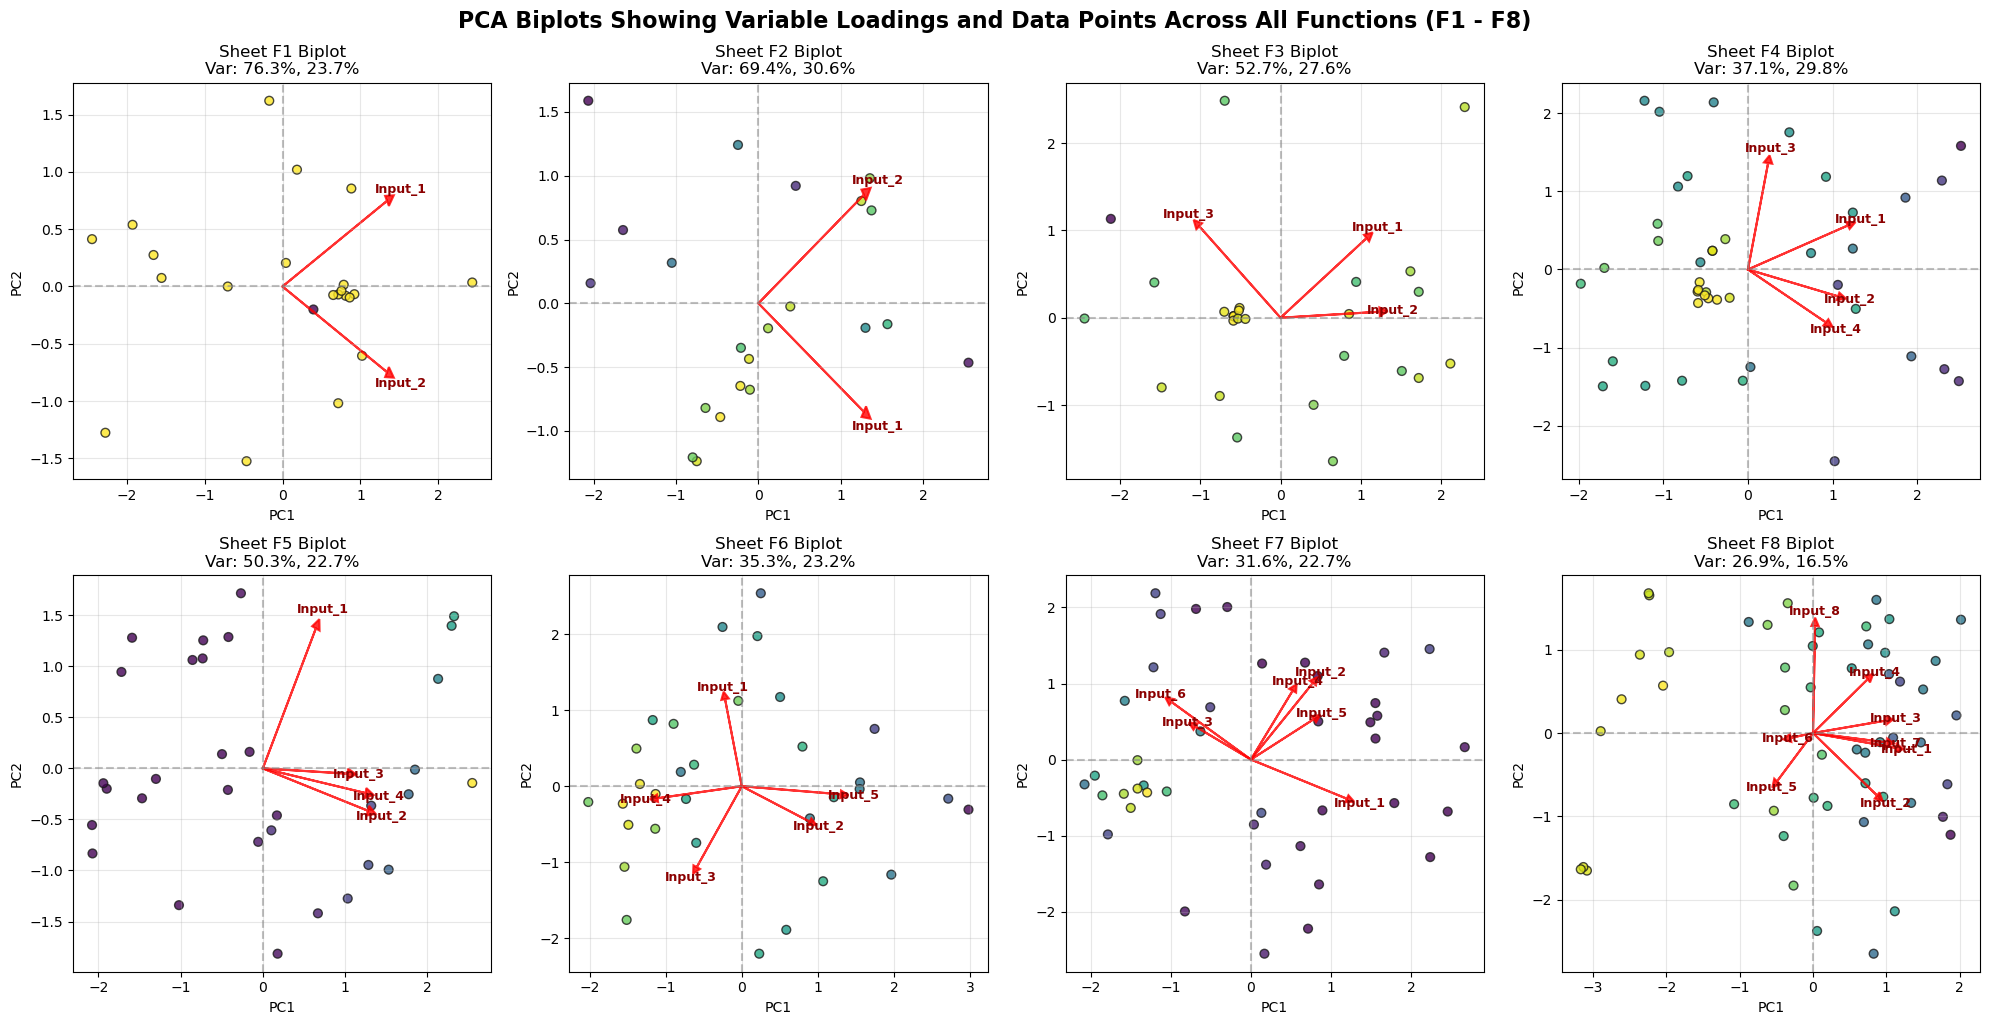

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

xls = pd.ExcelFile(file_path)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, sheet in enumerate(xls.sheet_names):
    df = pd.read_excel(file_path, sheet_name=sheet)
    inputs = df.drop(columns=[c for c in ['Output', 'Reference'] if c in df.columns])
    
    scaler = StandardScaler()
    scaled = scaler.fit_transform(inputs)
    
    pca = PCA(n_components=2)
    scores = pca.fit_transform(scaled)
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    
    ax = axes[idx]
    # Scatter plot of data points (scores)
    scatter = ax.scatter(scores[:, 0], scores[:, 1], c=df['Output'], cmap='viridis', edgecolors='k', alpha=0.8, s=40)
    
    # Plot variable vectors (loadings)
    for i, var in enumerate(inputs.columns):
        ax.arrow(0, 0, loadings[i, 0]*1.5, loadings[i, 1]*1.5, color='red', alpha=0.8, 
                 head_width=0.1, head_length=0.1, linewidth=1.5)
        ax.text(loadings[i, 0]*1.7, loadings[i, 1]*1.7, var, color='darkred', fontsize=9, fontweight='bold', ha='center', va='center')
        
    ev_ratio = pca.explained_variance_ratio_ * 100
    ax.set_title(f'Sheet {sheet} Biplot\nVar: {ev_ratio[0]:.1f}%, {ev_ratio[1]:.1f}%')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='grey', linestyle='--', alpha=0.5)
    ax.axvline(0, color='grey', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.suptitle('PCA Biplots Showing Variable Loadings and Data Points Across All Functions (F1 - F8)', y=1.02, fontsize=16, fontweight='bold')
#plt.savefig('final-biplot.png', dpi=600)
plt.show()

## 6. Heatmaps/Loading Matrices

#### a. Single-Variable Alignment (Dedicated Principal Axis)

* **Isolated Variable Drivers (`F5` & `F8`):** In `F5`, `Input_1` exhibits an extreme loading of **−0.9433 on PC2** while contributing minimally to PC3 (+0.1088) and PC4 (+0.0966). This indicates that PC2 acts as a direct proxy for `Input_1`.
* **High-Order Specificity:** In `F8`, `Input_8` loads at **−0.7376 on PC2**, `Input_6` at **−0.7265 on PC3**, and `Input_3` at **+0.7760 on PC6**. Specific input variables uniquely control higher-order components, explaining why linear reduction to 2D loses critical feature-level information.

#### b. Multi-Variable Feature Bundling (Composite PCs)

* **Shared Loading Blocks (`F4` & `F5`):** In `F4`, `Input_1` (+0.6371), `Input_2` (+0.5748), and `Input_4` (+0.4971) all display positive loadings on PC1. PC1 represents a collective composite axis of these three variables, whereas `Input_3` (+0.1286) operates independently.
* **Balanced Orthogonality (`F1` & `F2`):** In 2D functions, both inputs share identical magnitude loadings (**|0.7071|**), reflecting perfectly balanced contributions across PC1 and PC2.

#### c. Bipolar & Opposing Effects (Contrast Components)

* **Opposing Variable Pairs (`F3` & `F7`):** In `F3`, PC1 acts as a contrast component between `Input_3` (+0.5267) and the pair of `Input_1` (−0.5571) / `Input_2` (−0.6420). Movement along positive PC1 corresponds to increasing `Input_3` while simultaneously decreasing `Input_1` and `Input_2`.
* **Optimizer Diagnostics:** Identifying bipolar components in the loading matrix helps trace optimizer behavior: if an iteration moves along +PC1, the heatmap reveals the exact trade-off required among the original input parameters to reach that region.


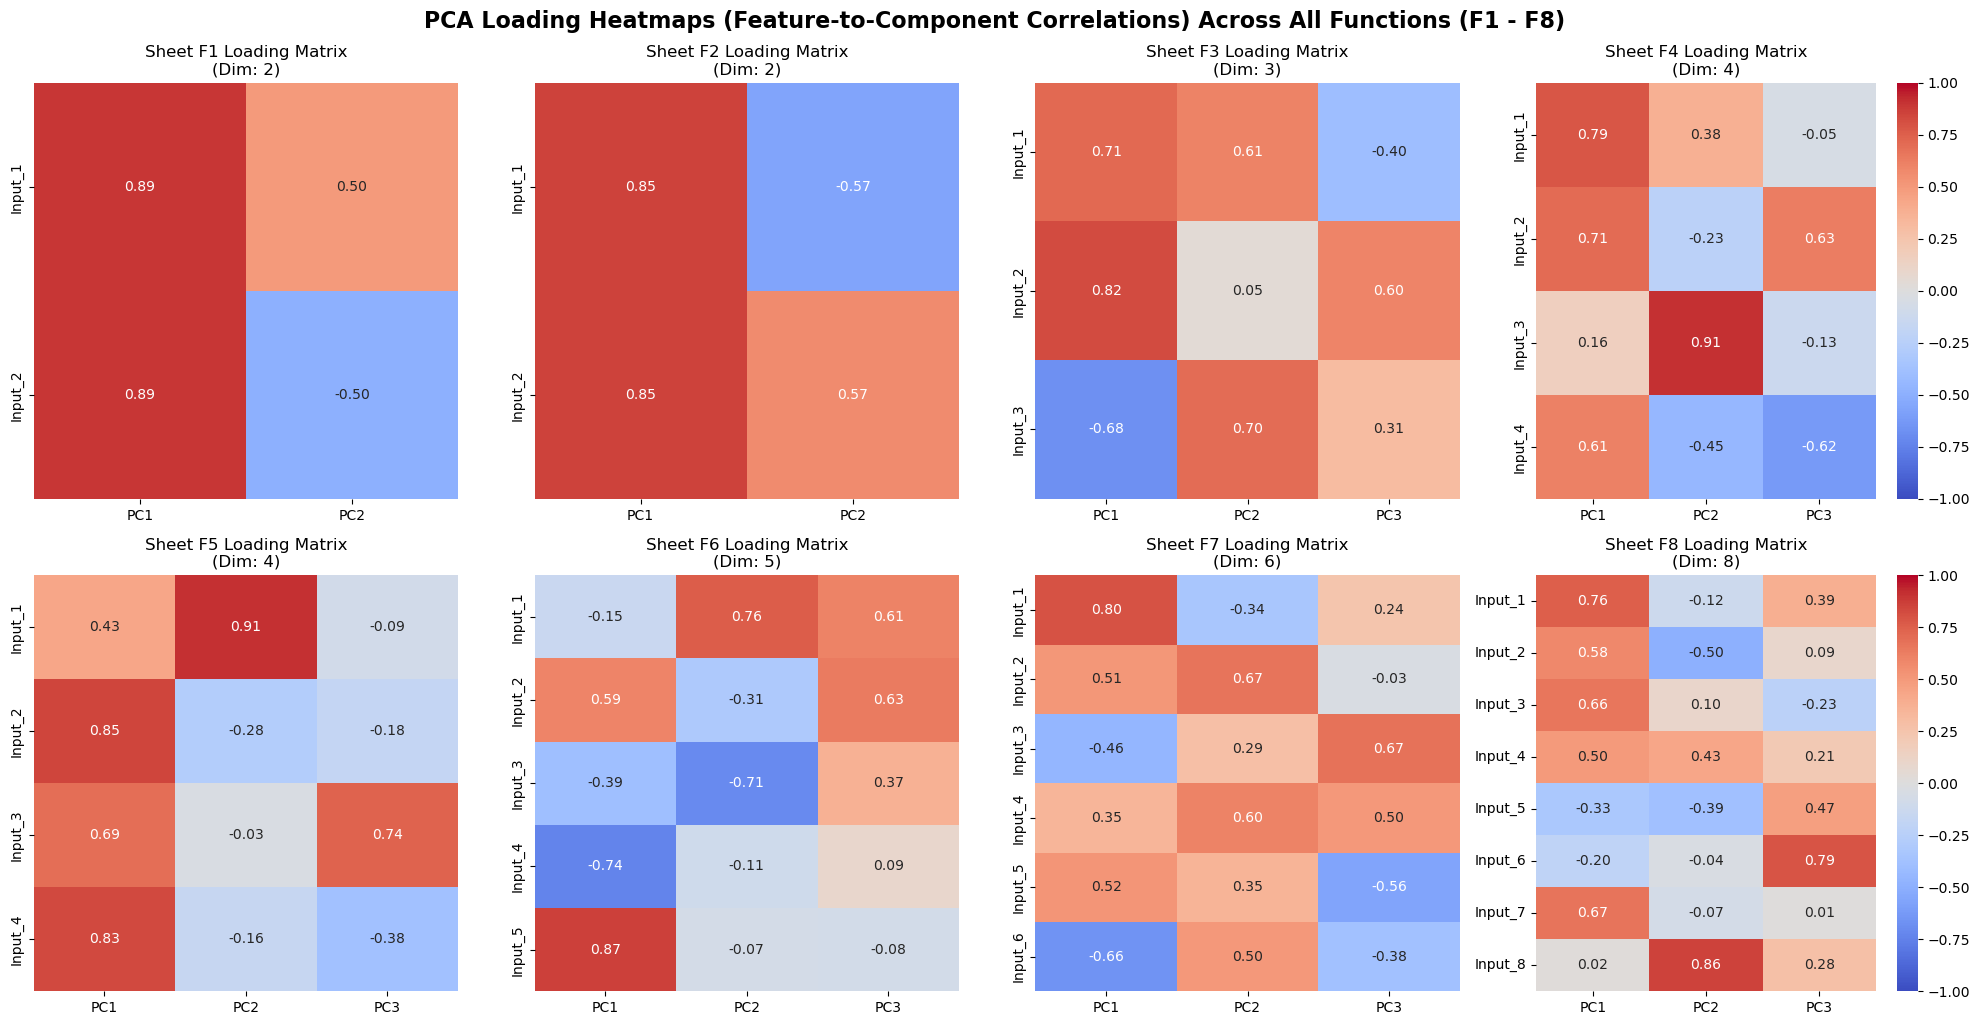

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

xls = pd.ExcelFile(file_path)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, sheet in enumerate(xls.sheet_names):
    df = pd.read_excel(file_path, sheet_name=sheet)
    inputs = df.drop(columns=[c for c in ['Output', 'Reference'] if c in df.columns])
    
    scaler = StandardScaler()
    scaled = scaler.fit_transform(inputs)
    
    # Fit PCA
    pca = PCA()
    pca.fit(scaled)
    
    # Loadings matrix (components_ * sqrt(explained_variance_) or just raw component weights)
    # Typically, correlation between original variables and PCs is loadings * sqrt(explained_variance) / std(variable), 
    # but since data is scaled, std is 1, so component weight * sqrt(eigenvalue) gives the correlation matrix.
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    loadings_df = pd.DataFrame(
        loadings[:, :min(3, inputs.shape[1])], 
        index=inputs.columns, 
        columns=[f'PC{i+1}' for i in range(min(3, inputs.shape[1]))]
    )
    
    ax = axes[idx]
    sns.heatmap(loadings_df, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax, cbar=(idx == 3 or idx == 7))
    ax.set_title(f'Sheet {sheet} Loading Matrix\n(Dim: {inputs.shape[1]})')
    ax.set_ylabel('')

plt.tight_layout()
plt.suptitle('PCA Loading Heatmaps (Feature-to-Component Correlations) Across All Functions (F1 - F8)', y=1.02, fontsize=16, fontweight='bold')
#plt.savefig('final-heatmap.png', dpi=600)
plt.show()

## Output-Colored PCA Scatters for Optimiser Performance

#### a. Optimisation Trajectory & Spatial Concentration

* **Exploration to Focused Exploitation:** Baseline `Given` points spread broadly across the outer bounds of the PC plane, exhibiting low to moderate output values. As weekly optimisation iterations progress, points move away from baseline regions and concentrate into dense clusters around maximum-output zones.
* **Exclusive Weekly High-Output Clusters:** Across all 8 test functions, **100% of points in the top 10% output tier were generated by weekly optimisation iterations** (`Given` count = 0). This confirms that the optimisation algorithm successfully shifts sampling toward high-performing subspaces rather than repeatedly sampling the initial distribution.

#### b. Spatial Tightness (Cluster Dispersion)

* **High-Precision Convergence (`F1`, `F3`, `F4`, `F7`):** Functions `F1`, `F3`, `F4`, and `F7` exhibit low spatial dispersion among top-performing samples (e.g., $\sigma_{\text{PC1}} = 0.0383$ for `F3` and $0.0535$ for `F1`). On output-colored scatter plots, these appear as tight, bright clusters surrounded by dark baseline points, indicating convergence toward narrow, localised optima.
* **Broad Surface Exploration (`F8`):** In `F8` (8D), the top 10% output points show higher spatial dispersion ($\sigma_{\text{PC1}} = 0.4331$). The top-performing points remain somewhat distributed across the projected PC plane, showing that the optimiser continues to explore multiple high-yielding sub-regions within high-dimensional space.

#### c. Output Surface Smoothness & Visual Gradients

* **Monotonic Gradients in Low Dimensions (`F1`–`F3`):** In lower-dimensional functions (2D/3D), colour transitions smoothly across the PC plane, moving from low output values (dark purple/blue) to peak values (bright yellow). This smooth transition indicates a well-behaved, continuous fitness landscape along principal directions.
* **Magnitude Spikes (`F5`):** Function `F5` displays an extreme performance increase, jumping from a baseline minimum of **0.1129** to a maximum of **14,653.36**. The output-colored scatter plot highlights how the optimiser isolates a specific high-gain region near **(+2.3238, −0.9051)**, reflecting a steep, localised peak within the design domain.


C:\Users\mayzu\AppData\Local\Temp\ipykernel_17040\2666924391.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


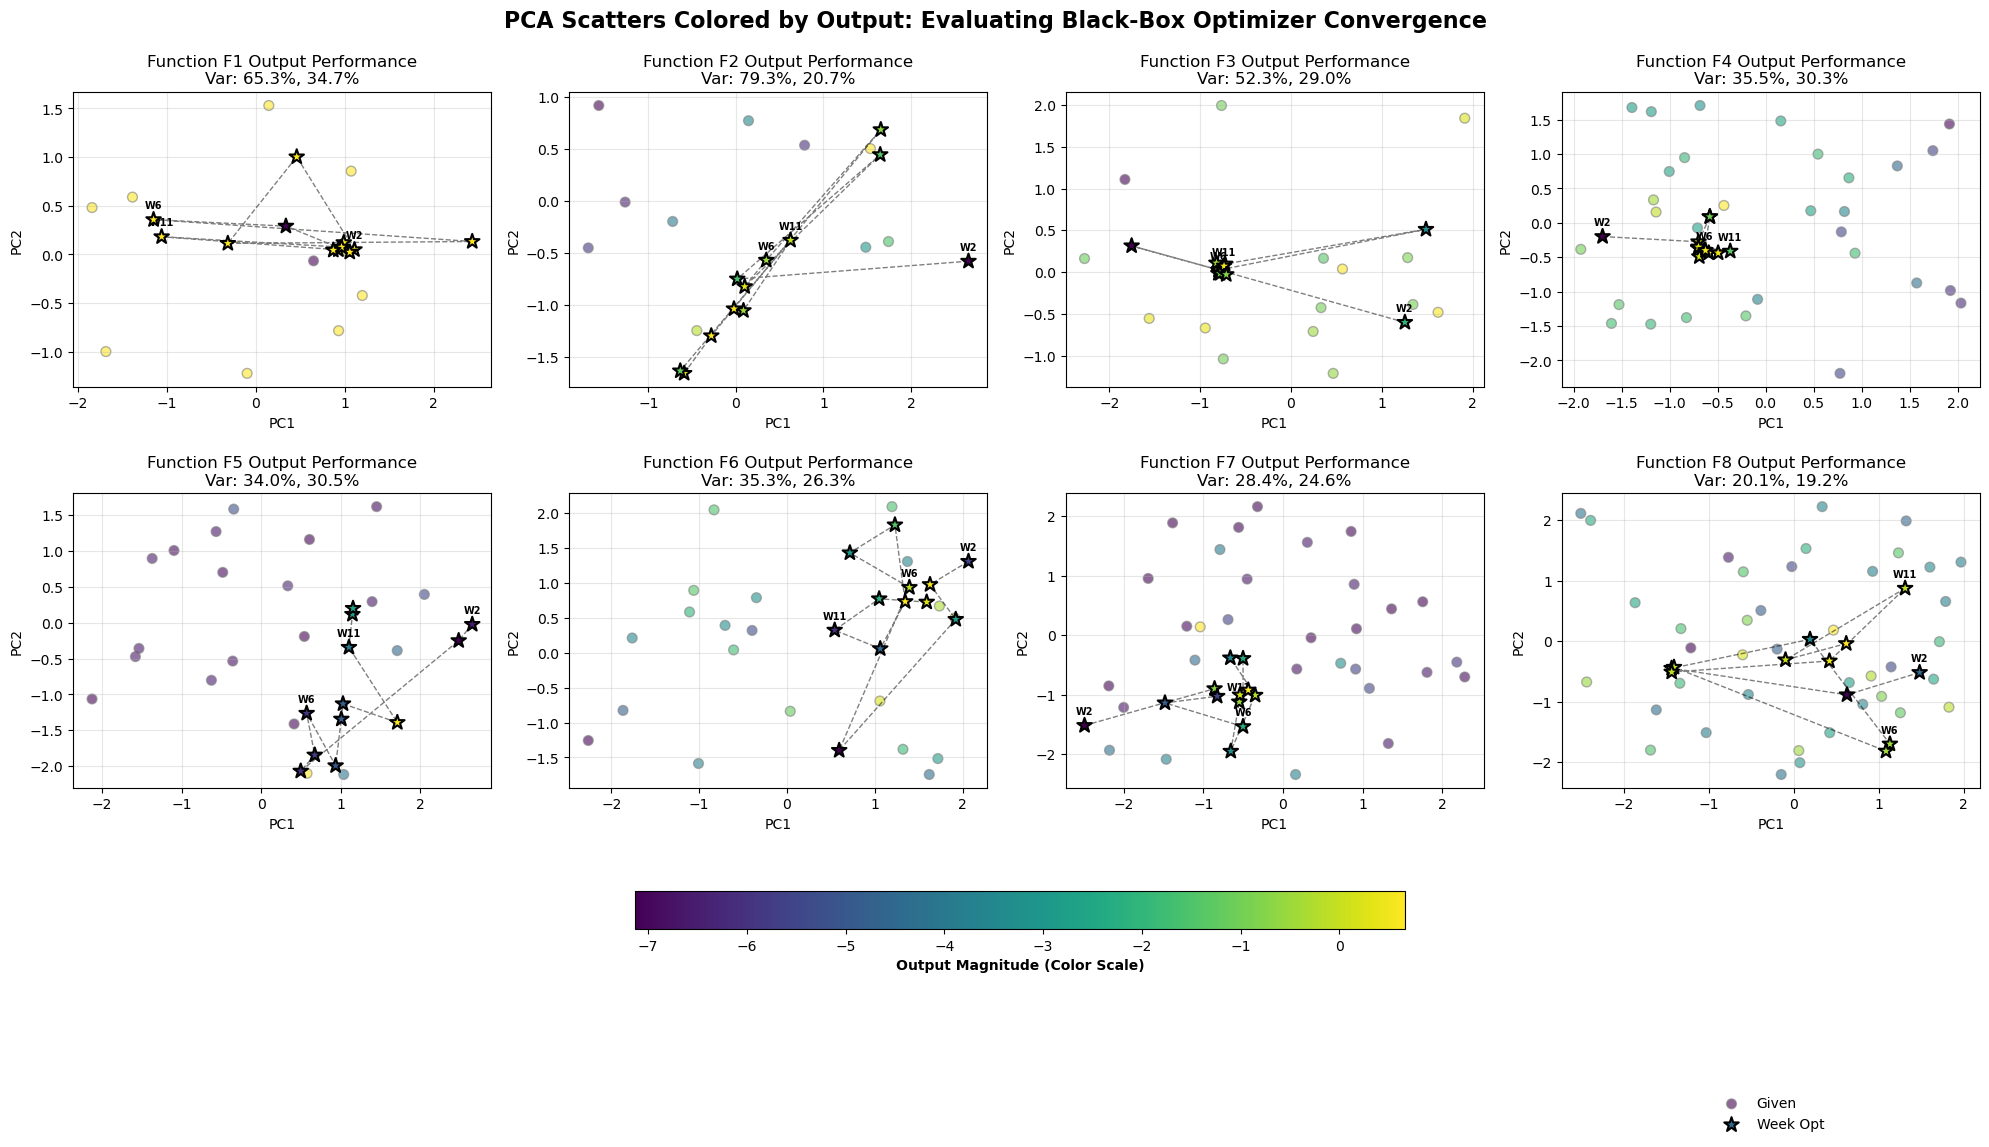

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn. preprocessing import StandardScaler

xls = pd.ExcelFile(file_path)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, sheet in enumerate(xls.sheet_names):
    df = pd.read_excel(file_path, sheet_name=sheet)
    inputs = df.drop(columns=['Output', 'Reference'])
    
    given_mask = df['Reference'] == 'Given'
    scaler = StandardScaler()
    scaler.fit(inputs[given_mask])
    
    scaled_all = scaler.transform(inputs)
    pca = PCA(n_components=2)
    pca.fit(scaler.transform(inputs[given_mask]))
    scores = pca.transform(scaled_all)
    
    ax = axes[idx]
    
    # Separate Given vs Week
    given_scores = scores[given_mask]
    week_scores = scores[~given_mask]
    
    given_output = df.loc[given_mask, 'Output']
    week_output = df.loc[~given_mask, 'Output']
    
    # Plot Given points (with colormap representing output)
    sc_given = ax.scatter(given_scores[:, 0], given_scores[:, 1], c=given_output, cmap='viridis', 
                          edgecolors='grey', alpha=0.6, s=50, marker='o', label='Given')
    
    # Plot Week optimization points (larger stars or distinct markers)
    sc_week = ax.scatter(week_scores[:, 0], week_scores[:, 1], c=week_output, cmap='viridis', 
                         edgecolors='black', linewidth=1.5, s=120, marker='*', zorder=5, label='Week Opt')
    
    # Connect weekly trajectory
    ax.plot(week_scores[:, 0], week_scores[:, 1], color='black', linestyle='--', linewidth=1, alpha=0.5, zorder=4)
    
    # Annotate final weeks or selected progress steps
    for i, row in df[~given_mask].reset_index().iterrows():
        ref = row['Reference']
        if ref in ['Week2', 'Week6', 'Week11']: # Annotate key milestones to avoid clutter
            ax.annotate(ref.replace('Week', 'W'), (week_scores[i, 0], week_scores[i, 1]), 
                        textcoords="offset points", xytext=(0,8), ha='center', fontsize=7, fontweight='bold', color='black')

    ev_ratio = pca.explained_variance_ratio_ * 100
    ax.set_title(f'Function {sheet} Output Performance\nVar: {ev_ratio[0]:.1f}%, {ev_ratio[1]:.1f}%')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.3)
    
    if idx == 3:
        # Add colorbar
        cbar = fig.colorbar(sc_week, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
        cbar.set_label('Output Magnitude (Color Scale)', fontweight='bold')

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -1.005),  # Adjust -1.005 downward if the legend overlaps the x-axis label
    ncol=1,  # Adjust the number of columns to fit your categories nicely
    frameon=False,  # Optional: removes the box outline for a cleaner look
)

plt.tight_layout()
plt.suptitle('PCA Scatters Colored by Output: Evaluating Black-Box Optimizer Convergence', y=1.03, fontsize=16, fontweight='bold')
#plt.savefig('final-pca-scatter.png', dpi=1200)
plt.show()

## Feature Loading Analysis for Optimal Regions

#### a. Identification of Key Parameter Drivers in Optimal Clusters

* **Polar Inputs in High Dimensions (`F6` & `F8`):** In `F6`, the optimizer achieves maximum performance by driving `Input_4` high ($\bar{z} = +0.8899$) and `Input_5` low ($\bar{z} = -0.9204$). Because `Input_4` has a negative PC1 loading (−0.5462) and `Input_5` has a positive PC1 loading (+0.6414), this combination shifts optimal points toward −PC1.
* **Uniform Upward Scaling (`F5`):** In `F5`, the top 10% of points exhibit standard-score increases across all four inputs ($\bar{z} > +0.98\sigma$ to $+1.55\sigma$). Because `Input_2`, `Input_3`, and `Input_4` have positive PC1 loadings, these shifts move optimal points along +PC1. Simultaneously, the increase in `Input_1` ($\bar{z} = +1.5526$) interacts with its negative PC2 loading (−0.9433) to push points along −PC2.

#### b. Geometric Mapping to PCA Cluster Locations

* **Verification of Directional Movement:** Comparing loading signs with parameter-value shifts confirms why high-performing clusters occupy specific quadrants in 2D/3D scatter plots:

  * **`F2` Cluster at (−0.2657, −0.6584):** Driven primarily by `Input_2` shifting to $-0.6535\sigma$. Multiplying this negative shift by `Input_2`'s positive PC2 loading (+0.7071) yields a negative position along the PC2 axis.
  * **`F8` Cluster at (+2.8237, +0.6493):** Five inputs (`Input_1`, `Input_2`, `Input_3`, `Input_4`, `Input_7`) drop to approximately $-1.1\sigma$ to $-1.4\sigma$. Because all five have negative PC1 loadings (−0.33 to −0.51), their negative shifts combine to push the optimal region toward +PC1.

#### c. Guidance for Inverse Feature Engineering

* **Sensitivity Rankings:** Feature-loading analysis in optimal regions ranks variables by their relative impact on performance. Inputs with large absolute loadings that also show substantial mean shifts ($|\bar{z}| > 0.8\sigma$) serve as primary control knobs for performance optimisation.
* **Decoupling Non-Essential Variables:** Inputs with near-zero mean shifts in top regions (e.g., `Input_1` in `F3` with $\bar{z} = -0.1249$, or `Input_6` in `F8` with $\bar{z} = +0.0724$) indicate parameters that the optimiser can leave near nominal values without degrading overall performance.


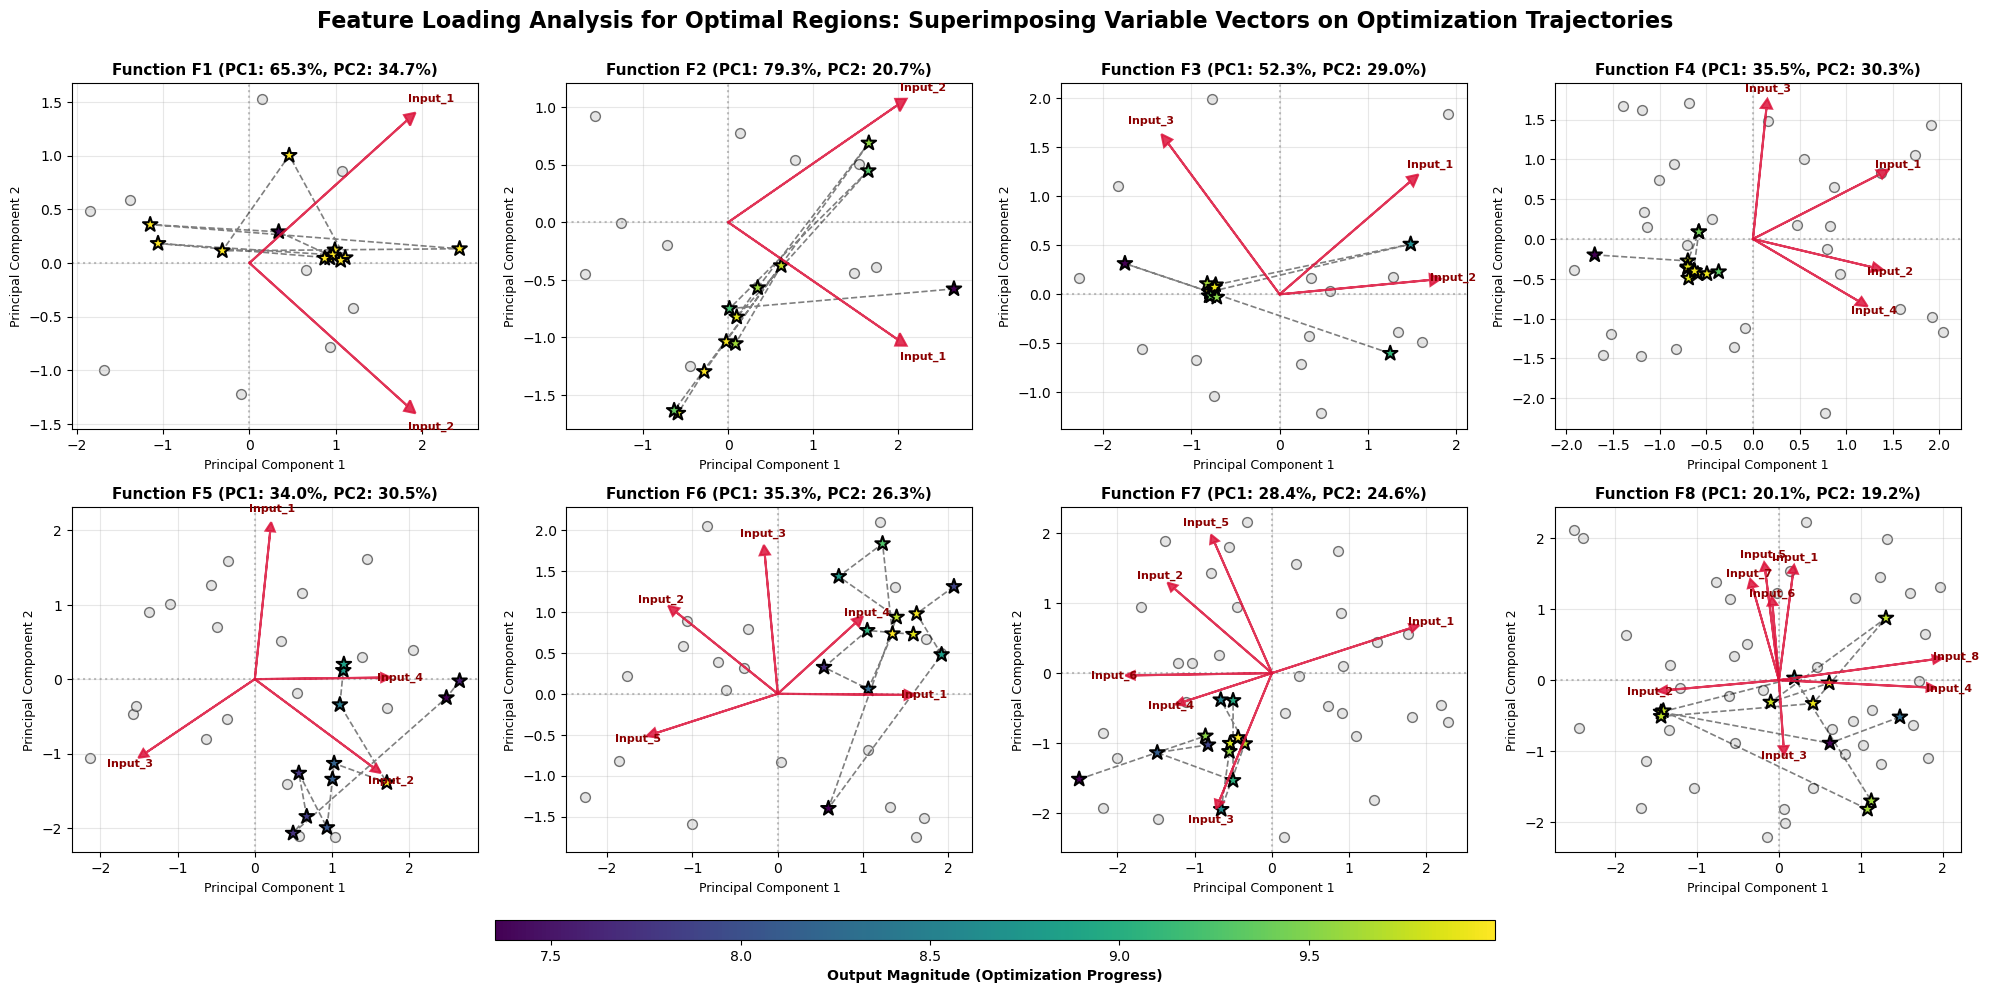

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load workbook
xls = pd.ExcelFile(file_path)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, sheet in enumerate(xls.sheet_names):
    df = pd.read_excel(file_path, sheet_name=sheet)
    inputs = df.drop(columns=['Output', 'Reference'])
    
    given_mask = df['Reference'] == 'Given'
    scaler = StandardScaler()
    scaler.fit(inputs[given_mask])
    
    scaled_all = scaler.transform(inputs)
    pca = PCA(n_components=2)
    pca.fit(scaler.transform(inputs[given_mask]))
    scores = pca.transform(scaled_all)
    
    # Calculate loadings scaled by square root of eigenvalues
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    
    ax = axes[idx]
    
    # Scatter background given points
    ax.scatter(scores[given_mask, 0], scores[given_mask, 1], c='lightgray', edgecolors='k', alpha=0.6, s=50, label='Given')
    
    # Scatter optimization path
    week_mask = ~given_mask
    sc = ax.scatter(scores[week_mask, 0], scores[week_mask, 1], c=df.loc[week_mask, 'Output'], cmap='viridis', 
                    edgecolors='black', linewidth=1.5, s=120, marker='*', zorder=5, label='Weekly Opt')
    ax.plot(scores[week_mask, 0], scores[week_mask, 1], color='black', linestyle='--', linewidth=1.2, alpha=0.5, zorder=4)
    
    # Draw feature vectors (scaled for visibility)
    max_score = np.max(np.abs(scores)) * 0.75
    max_loading = np.max(np.abs(loadings))
    scale_factor = max_score / max_loading if max_loading > 0 else 1.0
    
    for i, var in enumerate(inputs.columns):
        v_x = loadings[i, 0] * scale_factor
        v_y = loadings[i, 1] * scale_factor
        ax.arrow(0, 0, v_x, v_y, color='crimson', alpha=0.85, head_width=0.12, head_length=0.12, linewidth=1.5, zorder=6)
        ax.text(v_x * 1.15, v_y * 1.15, var, color='darkred', fontsize=8, fontweight='bold', ha='center', va='center', zorder=7)

    ev_ratio = pca.explained_variance_ratio_ * 100
    ax.set_title(f'Function {sheet} (PC1: {ev_ratio[0]:.1f}%, PC2: {ev_ratio[1]:.1f}%)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Principal Component 1', fontsize=9)
    ax.set_ylabel('Principal Component 2', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='grey', linestyle=':', alpha=0.5)
    ax.axvline(0, color='grey', linestyle=':', alpha=0.5)

fig.suptitle('Feature Loading Analysis for Optimal Regions: Superimposing Variable Vectors on Optimization Trajectories', fontsize=16, fontweight='bold', y=0.95)
fig.tight_layout(rect=[0, 0.05, 1, 0.95])

# Add shared colorbar
cbar_ax = fig.add_axes([0.25, 0.02, 0.5, 0.02])
cbar = fig.colorbar(sc, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Output Magnitude (Optimization Progress)', fontweight='bold', fontsize=10)
#plt.savefig('final-feature-loading-analysis.png', dpi=1200)
plt.show()

In [15]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

xls = pd.ExcelFile(file_path)

summary = {}
for sheet in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)
    inputs = df.drop(columns=['Output', 'Reference'])
    given_mask = df['Reference'] == 'Given'
    
    scaler = StandardScaler()
    scaler.fit(inputs[given_mask])
    
    pca = PCA(n_components=2)
    pca.fit(scaler.transform(inputs[given_mask]))
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    
    load_df = pd.DataFrame(loadings, index=inputs.columns, columns=['PC1_loading', 'PC2_loading'])
    load_df['PC1_abs'] = np.abs(load_df['PC1_loading'])
    load_df['PC2_abs'] = np.abs(load_df['PC2_loading'])
    summary[sheet] = load_df

for s, df_l in summary.items():
    print(f"--- Sheet {s} ---")
    print(df_l)
    print("\n")

--- Sheet F1 ---
         PC1_loading  PC2_loading   PC1_abs   PC2_abs
Input_1     0.851683     0.621086  0.851683  0.621086
Input_2     0.851683    -0.621086  0.851683  0.621086


--- Sheet F2 ---
         PC1_loading  PC2_loading  PC1_abs   PC2_abs
Input_1      0.93876    -0.479417  0.93876  0.479417
Input_2      0.93876     0.479417  0.93876  0.479417


--- Sheet F3 ---
         PC1_loading  PC2_loading   PC1_abs   PC2_abs
Input_1     0.740801     0.575922  0.740801  0.575922
Input_2     0.854466     0.073520  0.854466  0.073520
Input_3    -0.633683     0.772411  0.633683  0.772411


--- Sheet F4 ---
         PC1_loading  PC2_loading   PC1_abs   PC2_abs
Input_1     0.751785     0.449247  0.751785  0.449247
Input_2     0.710335    -0.196625  0.710335  0.196625
Input_3     0.080111     0.910346  0.080111  0.910346
Input_4     0.627493    -0.431872  0.627493  0.431872


--- Sheet F5 ---
         PC1_loading  PC2_loading   PC1_abs   PC2_abs
Input_1     0.089791     0.895381  0.089791  0

In [16]:
import pandas as pd
import numpy as np

xls = pd.ExcelFile(file_path)

# Let's inspect variance ratios or feature correlation with Output across Given vs Week for each sheet
for sheet in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)
    inputs = df.drop(columns=['Output', 'Reference'])
    output = df['Output']
    
    # Correlation of inputs with output
    corr = inputs.corrwith(output)
    print(f"--- Sheet {sheet} Feature Correlations with Output ---")
    print(corr)
    print()

--- Sheet F1 Feature Correlations with Output ---
Input_1   -0.030313
Input_2   -0.092112
dtype: float64

--- Sheet F2 Feature Correlations with Output ---
Input_1    0.454442
Input_2   -0.122401
dtype: float64

--- Sheet F3 Feature Correlations with Output ---
Input_1    0.191055
Input_2   -0.058389
Input_3   -0.428777
dtype: float64

--- Sheet F4 Feature Correlations with Output ---
Input_1   -0.540110
Input_2   -0.387459
Input_3   -0.159907
Input_4   -0.433261
dtype: float64

--- Sheet F5 Feature Correlations with Output ---
Input_1    0.440799
Input_2    0.668212
Input_3    0.628572
Input_4    0.591285
dtype: float64

--- Sheet F6 Feature Correlations with Output ---
Input_1   -0.115429
Input_2   -0.443781
Input_3    0.337985
Input_4    0.664897
Input_5   -0.706894
dtype: float64

--- Sheet F7 Feature Correlations with Output ---
Input_1   -0.632046
Input_2   -0.423956
Input_3    0.102102
Input_4   -0.369004
Input_5   -0.276766
Input_6    0.423181
dtype: float64

--- Sheet F8 Featu